In [1]:
import pdb
import os
from simstack4.wrapper import SimstackWrapper

In [2]:
path_json = os.path.join(os.environ['PICKLESPATH'],'simstack','stacked_flux_densities')

In [3]:
file_date = '20250622_185503'
file_config = 'cosmos25_uvj_direct.toml'
output_file = f'sed_grid_uvj_{file_date}.png'
file_json = f"cosmos25_stacking_{file_date}.json"

In [4]:
file_date = '20250623_080950'
file_config = 'cosmos20.toml'
output_file = f'sed_grid_uvj_{file_date}_farmer.png'
file_json = f"cosmos20_stacking_{file_date}.json"

In [5]:
file_date = '20250624_100039'
file_config = 'cosmos20.toml'
output_file = f'sed_grid_{file_date}_uVista_DR2.png'
file_json = f"uVista_DR2_stacking_{file_date}.json"

In [6]:
file_config = 'cosmos25_fixed.toml'
output_file = f'sed_grid_simstack3.png'
file_json = f"simstack3_results_converted.json"

In [7]:
file_date = '20250621_124530'
file_date = '20250621_143620'
file_date = '20250622_074942'
file_date = '20250622_080605'
file_date = '20250628_100707'
file_date = '20250628_150529'
file_date = '20250712_123431'
file_date = '20250712_124842'
file_config = 'cosmos25_luv_beta.toml'
output_file = f'sed_grid_luv_beta_{file_date}.png'
file_json = f"cosmos25_stacking_{file_date}.json"

In [8]:
file_config = 'cosmos25.toml'
output_file = f'sed_grid_nuvrj_simstack3.png'
file_json = f"simstack3_results_converted_2025-06-12"

In [9]:
file_date = '20250620_172457'
file_date = '20250622_181846'
file_date = '20250628_095509'
file_date = '20250628_102624'
file_date = '20250712_130435'
file_config = 'cosmos25.toml'
output_file = f'sed_grid_nuvrj_{file_date}.png'
file_json = f"cosmos25_stacking_{file_date}.json"

In [10]:
# Load and inspect
wrapper = SimstackWrapper(
    config=f"/Users/mviero/Repositories/simstack4/config/{file_config}"
)
wrapper.load_stacking_results(os.path.join(path_json,file_json))

# Check what we actually have
print("Stacking results attributes:")
if wrapper.stacking_results:
    print(dir(wrapper.stacking_results))
    for attr in dir(wrapper.stacking_results):
        if not attr.startswith('_'):
            value = getattr(wrapper.stacking_results, attr)
            #print(f"  {attr}: {type(value)} - {value}")

print("\nPopulation manager:")
print(f"  Type: {type(wrapper.population_manager)}")
print(f"  Length: {len(wrapper.population_manager) if wrapper.population_manager else 0}")

2025-07-13 20:14:01,095 - simstack4 - INFO - SimstackWrapper initialized
2025-07-13 20:14:01,097 - simstack4 - INFO - ✓ Stacking results loaded from JSON: /Users/mviero/data/Astronomy/pickles/simstack/stacked_flux_densities/cosmos25_stacking_20250712_130435.json
2025-07-13 20:14:01,097 - simstack4 - INFO -   - 107 populations
2025-07-13 20:14:01,098 - simstack4 - INFO -   - Config source: original file
2025-07-13 20:14:01,098 - simstack4 - INFO - Automatically loading catalog for analysis...
2025-07-13 20:14:01,099 - simstack4 - INFO - Loading catalog...
2025-07-13 20:14:01,099 - simstack4 - INFO - SkyCatalogs initialized with polars backend
2025-07-13 20:14:01,099 - simstack4 - INFO - Loading catalog: /Users/mviero/data/Astronomy/catalogs/cosmos/COSMOSWeb_mastercatalog_v1_galaxies_sn3.0_clean.parquet
2025-07-13 20:14:01,146 - simstack4 - INFO - Population splitting enabled: SplitType.LABELS
2025-07-13 20:14:01,169 - simstack4 - INFO - Creating populations from 60 bin combinations × 2 

In [11]:
wrapper.processed_results

In [12]:
wrapper.stacking_results.flux_densities.keys()

dict_keys(['mips_24', 'pacs_green', 'pacs_red', 'spire_psw', 'spire_pmw', 'spire_plw', 'scuba'])

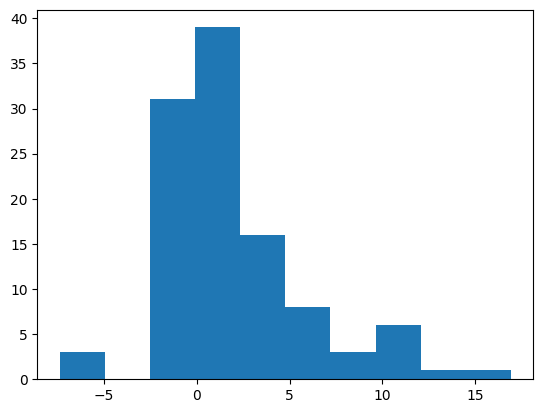

In [13]:
import matplotlib.pyplot as plt
import numpy as np
plt.hist(1e3*np.array(wrapper.stacking_results.flux_densities['spire_psw']));

In [28]:
wrapper.run_analysis_only(use_mcmc=False, use_schreiber_prior=True)
#wrapper.run_analysis_only(use_mcmc=True, use_schreiber_prior=True, mcmc_iterations=400)

2025-07-13 20:37:52,266 - simstack4 - INFO - Starting analysis pipeline with curve_fit fitting and Schreiber+2015 priors...
2025-07-13 20:37:52,268 - simstack4 - INFO - Cosmology initialized: Planck18
2025-07-13 20:37:52,269 - simstack4 - INFO - H0 = 67.7 km/s/Mpc, Ωm = 0.310, ΩΛ = 0.689
2025-07-13 20:37:52,270 - simstack4 - INFO - Processing stacking results...
✓ Population redshift_0.01_0.5__stellar_mass_8.5_9.5__split_0: L_IR = 1.49e+09 L_sun
✓ Population redshift_0.01_0.5__stellar_mass_8.5_9.5__split_1: L_IR = 9.93e+08 L_sun
✓ Population redshift_0.01_0.5__stellar_mass_9.5_10.0__split_0: L_IR = 1.12e+10 L_sun
✓ Population redshift_0.01_0.5__stellar_mass_9.5_10.0__split_1: L_IR = 2.92e+09 L_sun
✓ Population redshift_0.01_0.5__stellar_mass_10.0_10.5__split_0: L_IR = 2.80e+10 L_sun
✓ Population redshift_0.01_0.5__stellar_mass_10.0_10.5__split_1: L_IR = 6.49e+09 L_sun
✓ Population redshift_0.01_0.5__stellar_mass_10.5_11.0__split_0: L_IR = 4.24e+10 L_sun
✓ Population redshift_0.01_0.5__

In [29]:
wrapper.processed_results.print_results_summary();

=== Simstack4 Results Summary ===
Processed 107 populations
Bands: 7
Fitting method: curve_fit
Prior type: Schreiber+2015
Greybody fitting: β fixed = 1.8

Greybody Fit Success Rate: 85/107 (79.4%)
Rest-frame temperature range: 17.3 - 87.9 K (median: 40.2 K)
Observed-frame temperature range: 8.0 - 22.6 K (median: 12.2 K)
χ²_red range: 0.00 - 1109.56 (median: 16.36)

Fit Quality:
  mips_24 (24.0μm): χ²_red = 18.48
  pacs_green (100.0μm): χ²_red = 0.18
  pacs_red (160.0μm): χ²_red = 227556.01
  spire_psw (250.0μm): χ²_red = 10.46
  spire_pmw (350.0μm): χ²_red = 6.68
  spire_plw (500.0μm): χ²_red = 2.46
  scuba (850.0μm): χ²_red = 0.00

Population Results:
Population                     N_src    z_med    T_rest[K]  T_obs[K]   L_IR[L☉]     SFR[M☉/yr]  
--------------------------------------------------------------------------------------------------------------
redshift_0.01_0.5__stellar_ma  3681     0.35     28.6       21.2       1.49e+09     0.1         
redshift_0.01_0.5__stellar_ma  655

In [18]:
wrapper.processed_results.print_results_summary();

=== Simstack4 Results Summary ===
Processed 107 populations
Bands: 7
Fitting method: curve_fit
Prior type: flat
Greybody fitting: β fixed = 1.8

Greybody Fit Success Rate: 85/107 (79.4%)
Rest-frame temperature range: 17.3 - 114.8 K (median: 41.4 K)
Observed-frame temperature range: 8.0 - 24.0 K (median: 12.5 K)
χ²_red range: 0.00 - 1109.56 (median: 16.36)

Fit Quality:
  mips_24 (24.0μm): χ²_red = 18.48
  pacs_green (100.0μm): χ²_red = 0.18
  pacs_red (160.0μm): χ²_red = 227556.01
  spire_psw (250.0μm): χ²_red = 10.46
  spire_pmw (350.0μm): χ²_red = 6.68
  spire_plw (500.0μm): χ²_red = 2.46
  scuba (850.0μm): χ²_red = 0.00

Population Results:
Population                     N_src    z_med    T_rest[K]  T_obs[K]   L_IR[L☉]     SFR[M☉/yr]  
--------------------------------------------------------------------------------------------------------------
redshift_0.01_0.5__stellar_ma  3681     0.35     28.6       21.2       1.49e+09     0.1         
redshift_0.01_0.5__stellar_ma  655      0.3

In [30]:
# =============================================================================
# GENERALIZED SED GRID PLOT FOR SIMSTACK4 WRAPPER RESULTS
# Supports both population types and no population types
# Uses actual fitted parameters from wrapper.processed_results
# =============================================================================
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.colors import LogNorm
import seaborn as sns

def create_sed_grid_plot(wrapper, 
                         show_errors=True,
                         figsize=None,
                         max_panels=None,
                         save_path=None, xlim=None, ylim=None):
    """
    Create grid plot of SEDs (flux density vs wavelength) from SimstackWrapper results
    
    Parameters:
    -----------
    wrapper : SimstackWrapper
        Wrapper object with stacking_results and processed_results
    show_errors : bool
        Whether to show error bars
    figsize : tuple or None
        Figure size (width, height). If None, auto-calculated
    max_panels : int or None
        Maximum number of panels to show (for large grids)
    save_path : str or Path or None
        Path to save the figure (PDF, PNG, etc. based on extension)
    """
    
    # Get results from wrapper
    if not hasattr(wrapper, 'stacking_results') or wrapper.stacking_results is None:
        print("❌ No stacking results found in wrapper")
        return None
        
    if not hasattr(wrapper, 'processed_results') or wrapper.processed_results is None:
        print("❌ No processed results found in wrapper")
        return None
    
    stacking_results = wrapper.stacking_results
    processed_results = wrapper.processed_results
    
    # Get summary dataframe
    try:
        if hasattr(processed_results, 'get_population_summary'):
            summary_df = processed_results.get_population_summary()
        else:
            # Fallback to population manager
            summary_df = wrapper.population_manager.get_population_summary()
        
        print(f"📋 Available columns: {list(summary_df.columns)}")
        
    except Exception as e:
        print(f"❌ Could not get population summary: {e}")
        return None
    
    # Extract wavelengths from map names
    map_names = stacking_results.map_names
    wavelengths = []
    
    for map_name in map_names:
        if 'mips_24' in map_name or '24' in map_name:
            wavelengths.append(24.0)
        elif 'pacs_green' in map_name or '100' in map_name:
            wavelengths.append(100.0)
        elif 'pacs_red' in map_name or '160' in map_name:
            wavelengths.append(160.0)
        elif 'spire_psw' in map_name or '250' in map_name:
            wavelengths.append(250.0)
        elif 'spire_pmw' in map_name or '350' in map_name:
            wavelengths.append(350.0)
        elif 'spire_plw' in map_name or '500' in map_name:
            wavelengths.append(500.0)
        elif 'scuba' in map_name or '850' in map_name:
            wavelengths.append(850.0)
        else:
            # Try to extract number from name
            import re
            numbers = re.findall(r'\d+', map_name)
            if numbers:
                wavelengths.append(float(numbers[0]))
            else:
                wavelengths.append(len(wavelengths) * 100)  # Fallback
    
    wavelengths = np.array(wavelengths)
    print(f"📡 Available wavelengths: {wavelengths} μm")
    print(f"📊 Map names: {map_names}")
    
    # Filter for detected populations only
    df = summary_df.copy()
    
    # Check if we have L_IR measurements
    lir_cols = [col for col in df.columns if 'ir_luminosity' in col.lower()]
    if lir_cols:
        lir_col = lir_cols[0]
        df = df[df[lir_col] > 0]
        print(f"🔍 Using {lir_col} for detection filter")
    else:
        # Fallback: use number of sources
        df = df[df['n_sources'] > 0]
        print("🔍 Using n_sources > 0 for detection filter")
    
    if len(df) == 0:
        print("❌ No detected populations found XXX")
        return None
    
    print(f"✅ Found {len(df)} detected populations")
    
    # Parse population information to create grid
    def parse_population_id(pop_id):
        """Extract binning information from population ID"""
        try:
            parts = pop_id.split('__')
            bin_info = {}
            
            for part in parts:
                if '_' in part:
                    # Look for patterns like "redshift_0.5_1.0" or "l_uv_9.0_10.0"
                    elements = part.split('_')
                    if len(elements) >= 3:
                        # Try to find numeric ranges
                        try:
                            # Check if last two elements are numbers
                            min_val = float(elements[-2])
                            max_val = float(elements[-1])
                            bin_name = '_'.join(elements[:-2])
                            bin_info[bin_name] = (min_val, max_val)
                        except ValueError:
                            continue
            
            return bin_info
        except Exception as e:
            print(f"⚠️  Could not parse population ID: {pop_id}")
            return {}
    
    # Determine the correct population ID column name
    pop_id_col = None
    possible_id_cols = ['id_label', 'population_id', 'pop_id', 'label']
    
    for col in possible_id_cols:
        if col in df.columns:
            pop_id_col = col
            break
    
    if pop_id_col is None:
        print(f"❌ Could not find population ID column. Available columns: {list(df.columns)}")
        return None
    
    print(f"🏷️  Using population ID column: '{pop_id_col}'")
    
    # Parse all population IDs
    parsed_info = df[pop_id_col].apply(parse_population_id)
    
    # Find the most common binning dimensions
    all_bin_names = set()
    for info in parsed_info:
        all_bin_names.update(info.keys())
    
    print(f"🗂️  Detected binning dimensions: {list(all_bin_names)}")
    
    if len(all_bin_names) < 2:
        print("⚠️  Less than 2 binning dimensions found, creating simple plot")
        return create_simple_sed_plot(df, stacking_results, wavelengths, map_names, show_errors, pop_id_col)
    
    # Choose two primary dimensions for the grid
    # Priority: redshift, stellar_mass, l_uv, beta_uv
    priority_dims = ['redshift', 'stellar_mass', 'l_uv', 'beta_uv', 'mass', 'z']
    
    primary_dims = []
    for dim in priority_dims:
        matches = [name for name in all_bin_names if dim in name.lower()]
        if matches:
            primary_dims.extend(matches[:2])  # Take up to 2 matches
            if len(primary_dims) >= 2:
                break
    
    # If we still don't have 2 dimensions, take the first 2
    if len(primary_dims) < 2:
        primary_dims = list(all_bin_names)[:2]
    
    dim1, dim2 = primary_dims[0], primary_dims[1]
    print(f"📐 Grid dimensions: {dim1} (x-axis) × {dim2} (y-axis)")
    
    # Extract bin values for each dimension
    def get_bin_values(dim_name):
        values = []
        for info in parsed_info:
            if dim_name in info:
                min_val, max_val = info[dim_name]
                values.append((min_val, max_val))
        return sorted(list(set(values)))
    
    dim1_bins = get_bin_values(dim1)
    dim2_bins = get_bin_values(dim2)
    
    print(f"📊 Grid size: {len(dim1_bins)} × {len(dim2_bins)} = {len(dim1_bins) * len(dim2_bins)} panels")
    
    # Check if grid is too large
    if max_panels and len(dim1_bins) * len(dim2_bins) > max_panels:
        print(f"⚠️  Grid too large ({len(dim1_bins) * len(dim2_bins)} panels), truncating to {max_panels}")
        dim1_bins = dim1_bins[:int(np.sqrt(max_panels))]
        dim2_bins = dim2_bins[:int(np.sqrt(max_panels))]
    
    # Calculate figure size
    if figsize is None:
        figsize = (len(dim1_bins) * 2.8, len(dim2_bins) * 2.5)
    
    # Create the plot
    fig, axes = plt.subplots(len(dim2_bins), len(dim1_bins), figsize=figsize, 
                           sharex=True, sharey=True)
    
    # Handle single row/column cases
    if len(dim1_bins) == 1 and len(dim2_bins) == 1:
        axes = np.array([[axes]])
    elif len(dim1_bins) == 1:
        axes = axes.reshape(-1, 1)
    elif len(dim2_bins) == 1:
        axes = axes.reshape(1, -1)
    
    # Color scheme - try to detect population types
    has_split = any('split' in str(pop_id) for pop_id in df[pop_id_col])
    
    if has_split:
        color_map = {
            'split_0': '#FF6B6B',  # Star-forming (red)
            'split_1': '#4ECDC4',  # Quiescent (teal)
        }
        default_color = '#45B7D1'  # Blue
    else:
        default_color = '#45B7D1'  # Blue for all
    
    # Track panels with multiple populations for colorbar
    panels_with_multiple_pops = []
    max_pops_in_panel = 1
    
    # Plot each panel
    for i, dim2_bin in enumerate(dim2_bins):
        for j, dim1_bin in enumerate(dim1_bins):
            if len(dim2_bins) == 1 and len(dim1_bins) == 1:
                ax = axes[0, 0]
            elif len(dim2_bins) == 1:
                ax = axes[0, j]
            elif len(dim1_bins) == 1:
                ax = axes[i, 0]
            else:
                ax = axes[i, j]
            
            # Find populations for this bin
            pop_matches = []
            for idx, info in enumerate(parsed_info):
                if (dim1 in info and info[dim1] == dim1_bin and 
                    dim2 in info and info[dim2] == dim2_bin):
                    pop_matches.append(idx)
            
            if len(pop_matches) == 0:
                # No data for this bin
                ax.text(0.5, 0.5, 'No Data', ha='center', va='center', 
                       transform=ax.transAxes, fontsize=12, alpha=0.5)
                ax.set_xlim(11, 1000)
                ax.set_ylim(1e-3, 1e2)
            else:
                # Track max populations for colorbar
                max_pops_in_panel = max(max_pops_in_panel, len(pop_matches))
                
                # Create color spectrum if multiple populations
                if len(pop_matches) > 1:
                    # Use a colormap for multiple populations
                    import matplotlib.cm as cm
                    colors_for_panel = cm.viridis(np.linspace(0, 1, len(pop_matches)))
                    panels_with_multiple_pops.append((i, j, len(pop_matches)))
                else:
                    colors_for_panel = None
                
                # Collect legend entries for this panel
                legend_entries = []
                
                # Plot SEDs for all populations in this bin
                for pop_idx_in_panel, pop_idx in enumerate(pop_matches):
                    pop = df.iloc[pop_idx]
                    pop_id = pop[pop_id_col]
                    
                    # Get color for this population
                    if len(pop_matches) > 1 and colors_for_panel is not None:
                        # Use color spectrum
                        color = colors_for_panel[pop_idx_in_panel]
                    elif has_split:
                        if 'split_0' in str(pop_id):
                            color = color_map['split_0']
                        elif 'split_1' in str(pop_id):
                            color = color_map['split_1']
                        else:
                            color = default_color
                    else:
                        color = default_color
                    
                    # Get L_IR for legend
                    l_ir = pop.get('total_ir_luminosity_lsun', 0)
                    if l_ir > 0:
                        #log_l_ir = np.log10(l_ir)
                        log_l_ir = l_ir
                        legend_label = f"LIR/L☉={np.log10(l_ir):.2f}"
                    else:
                        legend_label = "No L_IR"
                    
                    legend_entries.append((color, legend_label))
                    pop = df.iloc[pop_idx]
                    pop_id = pop[pop_id_col]
                    
                    # Color is already determined above
                    
                    # Get flux measurements
                    try:
                        # Handle both list and numpy array cases
                        if hasattr(stacking_results.population_labels, 'index'):
                            result_pop_idx = stacking_results.population_labels.index(pop_id)
                        else:
                            # Convert to list if it's a numpy array
                            pop_labels_list = list(stacking_results.population_labels)
                            result_pop_idx = pop_labels_list.index(pop_id)
                        
                        fluxes = []
                        flux_errors = []
                        
                        for map_name in map_names:
                            flux = stacking_results.flux_densities[map_name][result_pop_idx] * 1e3  # Convert to mJy
                            flux_err = stacking_results.flux_errors[map_name][result_pop_idx] * 1e3
                            fluxes.append(flux)
                            flux_errors.append(flux_err)
                        
                        fluxes = np.array(fluxes)
                        flux_errors = np.array(flux_errors)
                        
                        # Plot detected points (positive flux) - CIRCLES ONLY
                        detected_mask = fluxes > 0
                        
                        if np.any(detected_mask):
                            if show_errors and np.any(flux_errors[detected_mask] > 0):
                                ax.errorbar(wavelengths[detected_mask], fluxes[detected_mask], 
                                          yerr=flux_errors[detected_mask],
                                          fmt='o', color=color, alpha=0.8, 
                                          markersize=6, capsize=2, linewidth=1.5)
                            else:
                                ax.plot(wavelengths[detected_mask], fluxes[detected_mask], 
                                      'o', color=color, alpha=0.8, markersize=6)
                            
                            # PLOT SED MODEL using results.py functions
                            try:
                                # Check what's available in processed_results
                                if hasattr(wrapper.processed_results, 'sed_results'):
                                    if pop_id in wrapper.processed_results.sed_results:
                                        sed_fit = wrapper.processed_results.sed_results[pop_id]
                                        
                                        # Check if we have the required attributes
                                        amplitude = getattr(sed_fit, 'amplitude', None)
                                        temperature = getattr(sed_fit, 'dust_temperature_observed_frame', None)
                                        beta = getattr(sed_fit, 'emissivity_index', 1.8) or 1.8
                                        
                                        if amplitude is not None and temperature is not None:
                                            # Generate model SED curve using results.py greybody_model
                                            model_wavelengths = np.logspace(1, 3, 50)  # Fewer points for speed
                                            
                                            # Use the actual greybody_model from results.py
                                            model_fluxes = wrapper.processed_results.greybody_fitter.greybody_model(
                                                model_wavelengths, amplitude, temperature, beta
                                            )
                                            
                                            # Plot model curve - CONVERT TO mJy
                                            ax.plot(model_wavelengths, model_fluxes * 1e3, '-', 
                                                   color=color, alpha=0.6, linewidth=2, zorder=1)
                                
                            except Exception as e:
                                print(f"❌ Error plotting SED model for {pop_id}: {e}")
                                pass  # Continue without SED model
                        
                        # Plot upper limits for non-detected points - CONVERT TO mJy
                        nondet_mask = (fluxes <= 0) | (fluxes < 2 * flux_errors)
                        if np.any(nondet_mask):
                            upper_limits = np.maximum(2 * flux_errors[nondet_mask], 0.1)
                            ax.plot(wavelengths[nondet_mask], upper_limits, 
                                  'v', color=color, alpha=0.4, markersize=3)
                        
                    except (ValueError, IndexError) as e:
                        print(f"⚠️  Could not find flux data for {pop_id}: {e}")
                        continue
                
                # Add single legend for this panel with all populations
                if legend_entries:
                    from matplotlib.lines import Line2D
                    legend_lines = []
                    legend_labels = []
                    
                    for color, label in legend_entries[::-1]:
                        legend_lines.append(Line2D([0], [0], color=color, linewidth=2))
                        legend_labels.append(label)
                    
                    ax.legend(legend_lines, legend_labels, loc='upper left', 
                             fontsize=8, frameon=True, fancybox=True, 
                             framealpha=0.8, edgecolor='gray')
            
            # Set log scales
            ax.set_xscale('log')
            ax.set_yscale('log')
            
            # Set limits
            #ax.set_xlim(np.min(wavelengths) * 0.8, np.max(wavelengths) * 1.2)
            if xlim is not None:
                ax.set_xlim(xlim)
            else:
                ax.set_xlim(11, np.max(wavelengths) * 1.2)
            if ylim is not None:
                ax.set_ylim(ylim)
            else:
                ax.set_ylim(1e-2, 1e3)
            
            # Grid
            ax.grid(True, alpha=0.3)
            
            # Labels for edge panels
            if i == len(dim2_bins) - 1:  # Bottom row
                ax.set_xlabel('Observed Wavelength (μm)', fontsize=12)
            if j == 0:  # Left column
                ax.set_ylabel('Flux Density (mJy)', fontsize=12)
            
            # Make tick labels bigger
            ax.tick_params(axis='both', which='major', labelsize=12)
            
            # Title for top row
            if i == 0:
                dim1_min, dim1_max = dim1_bin
                title = f"{dim1.replace('_', ' ')}: {dim1_min:.1f}-{dim1_max:.1f}"
                ax.set_title(title, fontsize=12)
            
            # Labels on right
            if j == len(dim1_bins) - 1:
                dim2_min, dim2_max = dim2_bin
                label = f"{dim2.replace('_', ' ')}: {dim2_min:.1f}-{dim2_max:.1f}"
                
                ax2 = ax.twinx()
                ax2.set_ylabel(label, rotation=270, labelpad=20, fontsize=12)
                ax2.set_yticks([])
    
    plt.tight_layout()
    
    # Add colorbar based on what we found
    if len(panels_with_multiple_pops) > 0:
        # Adjust layout to make room for colorbar
        plt.subplots_adjust(top=0.92, hspace=0.02, wspace=0.02, right=0.88)
        
        # Create colorbar for color spectrum
        import matplotlib.cm as cm
        from matplotlib.colors import Normalize
        
        # Use viridis colormap
        norm = Normalize(vmin=0, vmax=max_pops_in_panel-1)
        sm = plt.cm.ScalarMappable(cmap=cm.viridis, norm=norm)
        sm.set_array([])
        
        # Add colorbar
        cbar = fig.colorbar(sm, ax=axes, fraction=0.02, pad=0.02, aspect=30)
        cbar.set_label('Beta_UV', fontsize=12)
        cbar.ax.tick_params(labelsize=12)
        
    elif has_split:
        # No colorbar needed, just adjust layout
        plt.subplots_adjust(top=0.92, hspace=0.02, wspace=0.02)
    else:
        # No colorbar needed, just adjust layout
        plt.subplots_adjust(top=0.95, hspace=0.02, wspace=0.02)
    
    # Add overall title
    title = f"SED Grid: {len(df)} detected populations"
    if has_split and len(panels_with_multiple_pops) == 0:
        title += " (Red: SF, Teal: Q)"
    fig.suptitle(title, fontsize=12)
    
    # Save figure if path provided
    if save_path is not None:
        try:
            from pathlib import Path
            save_path = Path(save_path)
            save_path.parent.mkdir(parents=True, exist_ok=True)
            
            # Determine DPI based on file format
            dpi = 300 if save_path.suffix.lower() in ['.png', '.jpg', '.jpeg'] else 150
            
            plt.savefig(save_path, dpi=dpi, bbox_inches='tight', 
                       facecolor='white', edgecolor='none')
            print(f"💾 Figure saved to: {save_path}")
             
        except Exception as e:
            print(f"⚠️  Could not save figure: {e}")
    
    return fig

def create_simple_sed_plot(df, stacking_results, wavelengths, map_names, show_errors, pop_id_col):
    """
    Create simple SED plot when grid layout is not possible
    """
    fig, ax = plt.subplots(1, 1, figsize=(10, 6))
    
    colors = plt.cm.tab10(np.linspace(0, 1, len(df)))
    
    for idx, (_, pop) in enumerate(df.iterrows()):
        pop_id = pop[pop_id_col]  # Use the correct column name
        color = colors[idx]
        
        try:
            # Handle both list and numpy array cases for population labels
            if hasattr(stacking_results.population_labels, 'index'):
                result_pop_idx = stacking_results.population_labels.index(pop_id)
            else:
                pop_labels_list = list(stacking_results.population_labels)
                result_pop_idx = pop_labels_list.index(pop_id)
            
            fluxes = []
            flux_errors = []
            
            for map_name in map_names:
                flux = stacking_results.flux_densities[map_name][result_pop_idx] * 1e3
                flux_err = stacking_results.flux_errors[map_name][result_pop_idx] * 1e3
                fluxes.append(flux)
                flux_errors.append(flux_err)
            
            fluxes = np.array(fluxes)
            flux_errors = np.array(flux_errors)
            
            detected_mask = fluxes > 0
            
            if np.any(detected_mask):
                label = f"{pop_id.split('__')[0]}... (N={pop['n_sources']})"
                
                if show_errors:
                    ax.errorbar(wavelengths[detected_mask], fluxes[detected_mask], 
                              yerr=flux_errors[detected_mask],
                              fmt='o-', color=color, alpha=0.8, 
                              markersize=8, capsize=3, linewidth=2, label=label)
                else:
                    ax.plot(wavelengths[detected_mask], fluxes[detected_mask], 
                          'o-', color=color, alpha=0.8, markersize=8, label=label)
        
        except (ValueError, IndexError):
            continue
    
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_xlabel('Observed Wavelength (μm)', fontsize=12)
    ax.set_ylabel('Flux Density (mJy)', fontsize=12)
    ax.tick_params(axis='both', which='major', labelsize=14)
    ax.grid(True, alpha=0.3)
    ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=12)
    
    plt.tight_layout()
    
    return fig

📋 Available columns: ['population_id', 'n_sources', 'median_redshift', 'median_log_mass', 'n_bands', 'greybody_fit_success', 'dust_temperature_rest_frame_K', 'dust_temperature_observed_frame_K', 'dust_temperature_error_K', 'emissivity_index', 'chi2_reduced', 'total_ir_luminosity_lsun', 'total_ir_luminosity_error_lsun', 'dust_mass_msun', 'sfr_msun_yr', 'specific_sfr_yr']
📡 Available wavelengths: [ 24. 100. 160. 250. 350. 500. 850.] μm
📊 Map names: ['mips_24' 'pacs_green' 'pacs_red' 'spire_psw' 'spire_pmw' 'spire_plw'
 'scuba']
🔍 Using total_ir_luminosity_lsun for detection filter
✅ Found 73 detected populations
🏷️  Using population ID column: 'population_id'
🗂️  Detected binning dimensions: ['redshift', 'beta_uv', 'l_uv']
📐 Grid dimensions: redshift (x-axis) × l_uv (y-axis)
📊 Grid size: 8 × 3 = 24 panels
💾 Figure saved to: /Users/mviero/Desktop/sed_grid_luv_beta_20250712_124842.png


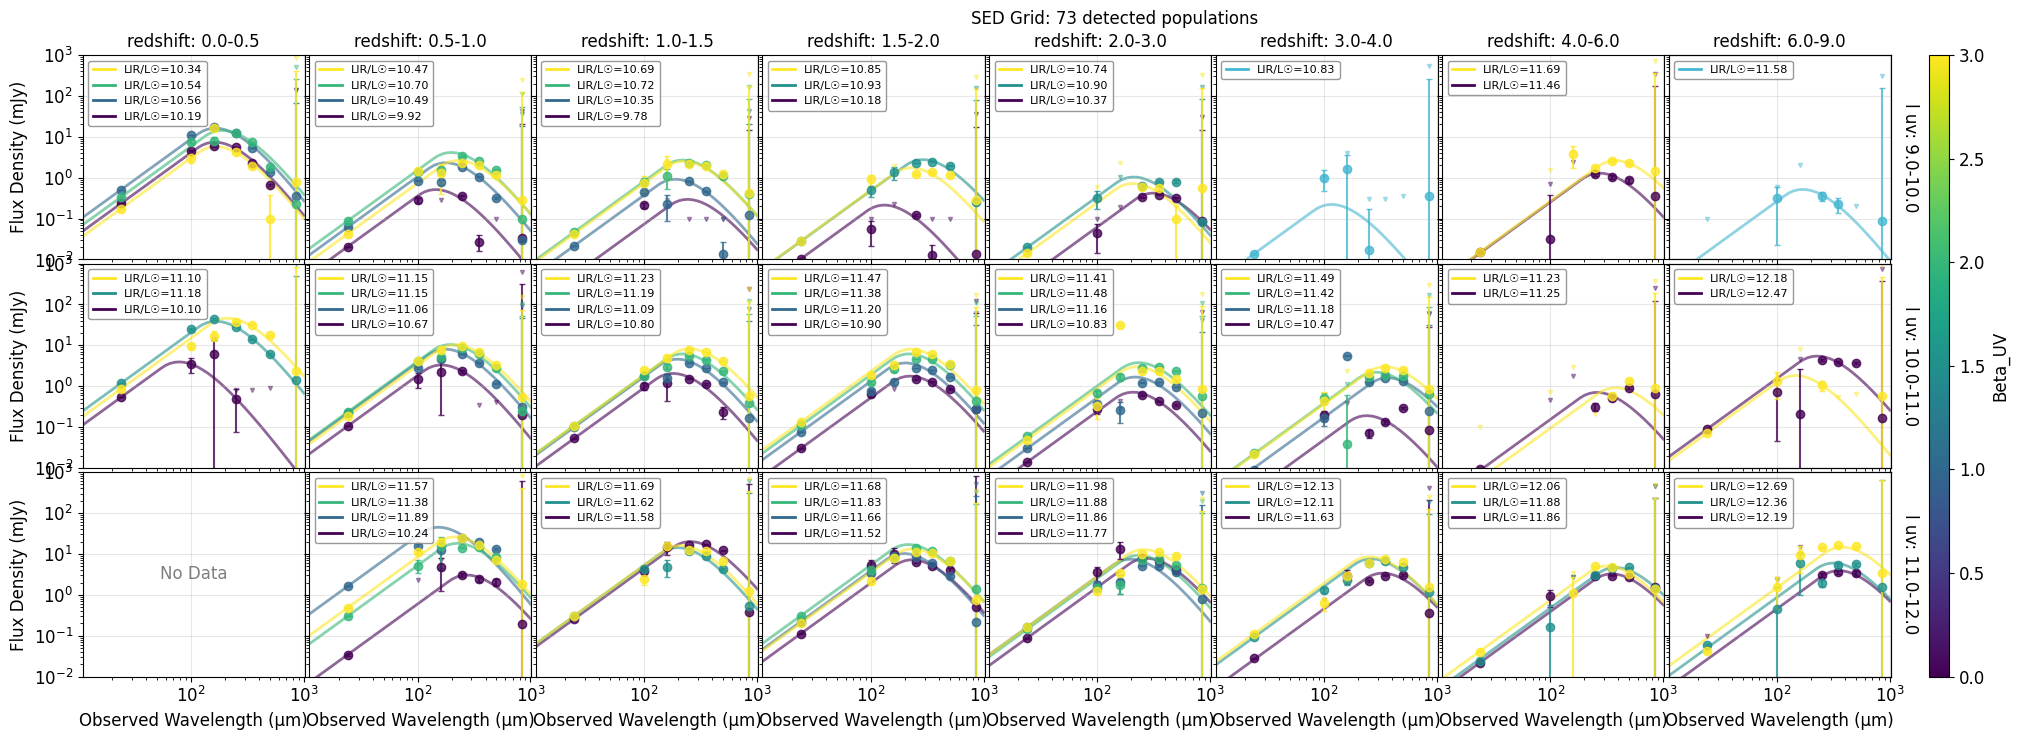

In [10]:
fig=create_sed_grid_plot(wrapper, save_path=f"/Users/mviero/Desktop/{output_file}")

📋 Available columns: ['population_id', 'n_sources', 'median_redshift', 'median_log_mass', 'n_bands', 'greybody_fit_success', 'dust_temperature_rest_frame_K', 'dust_temperature_observed_frame_K', 'dust_temperature_error_K', 'emissivity_index', 'chi2_reduced', 'total_ir_luminosity_lsun', 'total_ir_luminosity_error_lsun', 'dust_mass_msun', 'sfr_msun_yr', 'specific_sfr_yr', 'mcmc_used', 'mcmc_n_samples']
📡 Available wavelengths: [ 24. 100. 160. 250. 350. 500. 850.] μm
📊 Map names: ['mips_24' 'pacs_green' 'pacs_red' 'spire_psw' 'spire_pmw' 'spire_plw'
 'scuba']
🔍 Using total_ir_luminosity_lsun for detection filter
✅ Found 85 detected populations
🏷️  Using population ID column: 'population_id'
🗂️  Detected binning dimensions: ['redshift', 'stellar_mass']
📐 Grid dimensions: redshift (x-axis) × stellar_mass (y-axis)
📊 Grid size: 11 × 5 = 55 panels
💾 Figure saved to: /Users/mviero/Desktop/sed_grid_nuvrj_20250712_130435.png


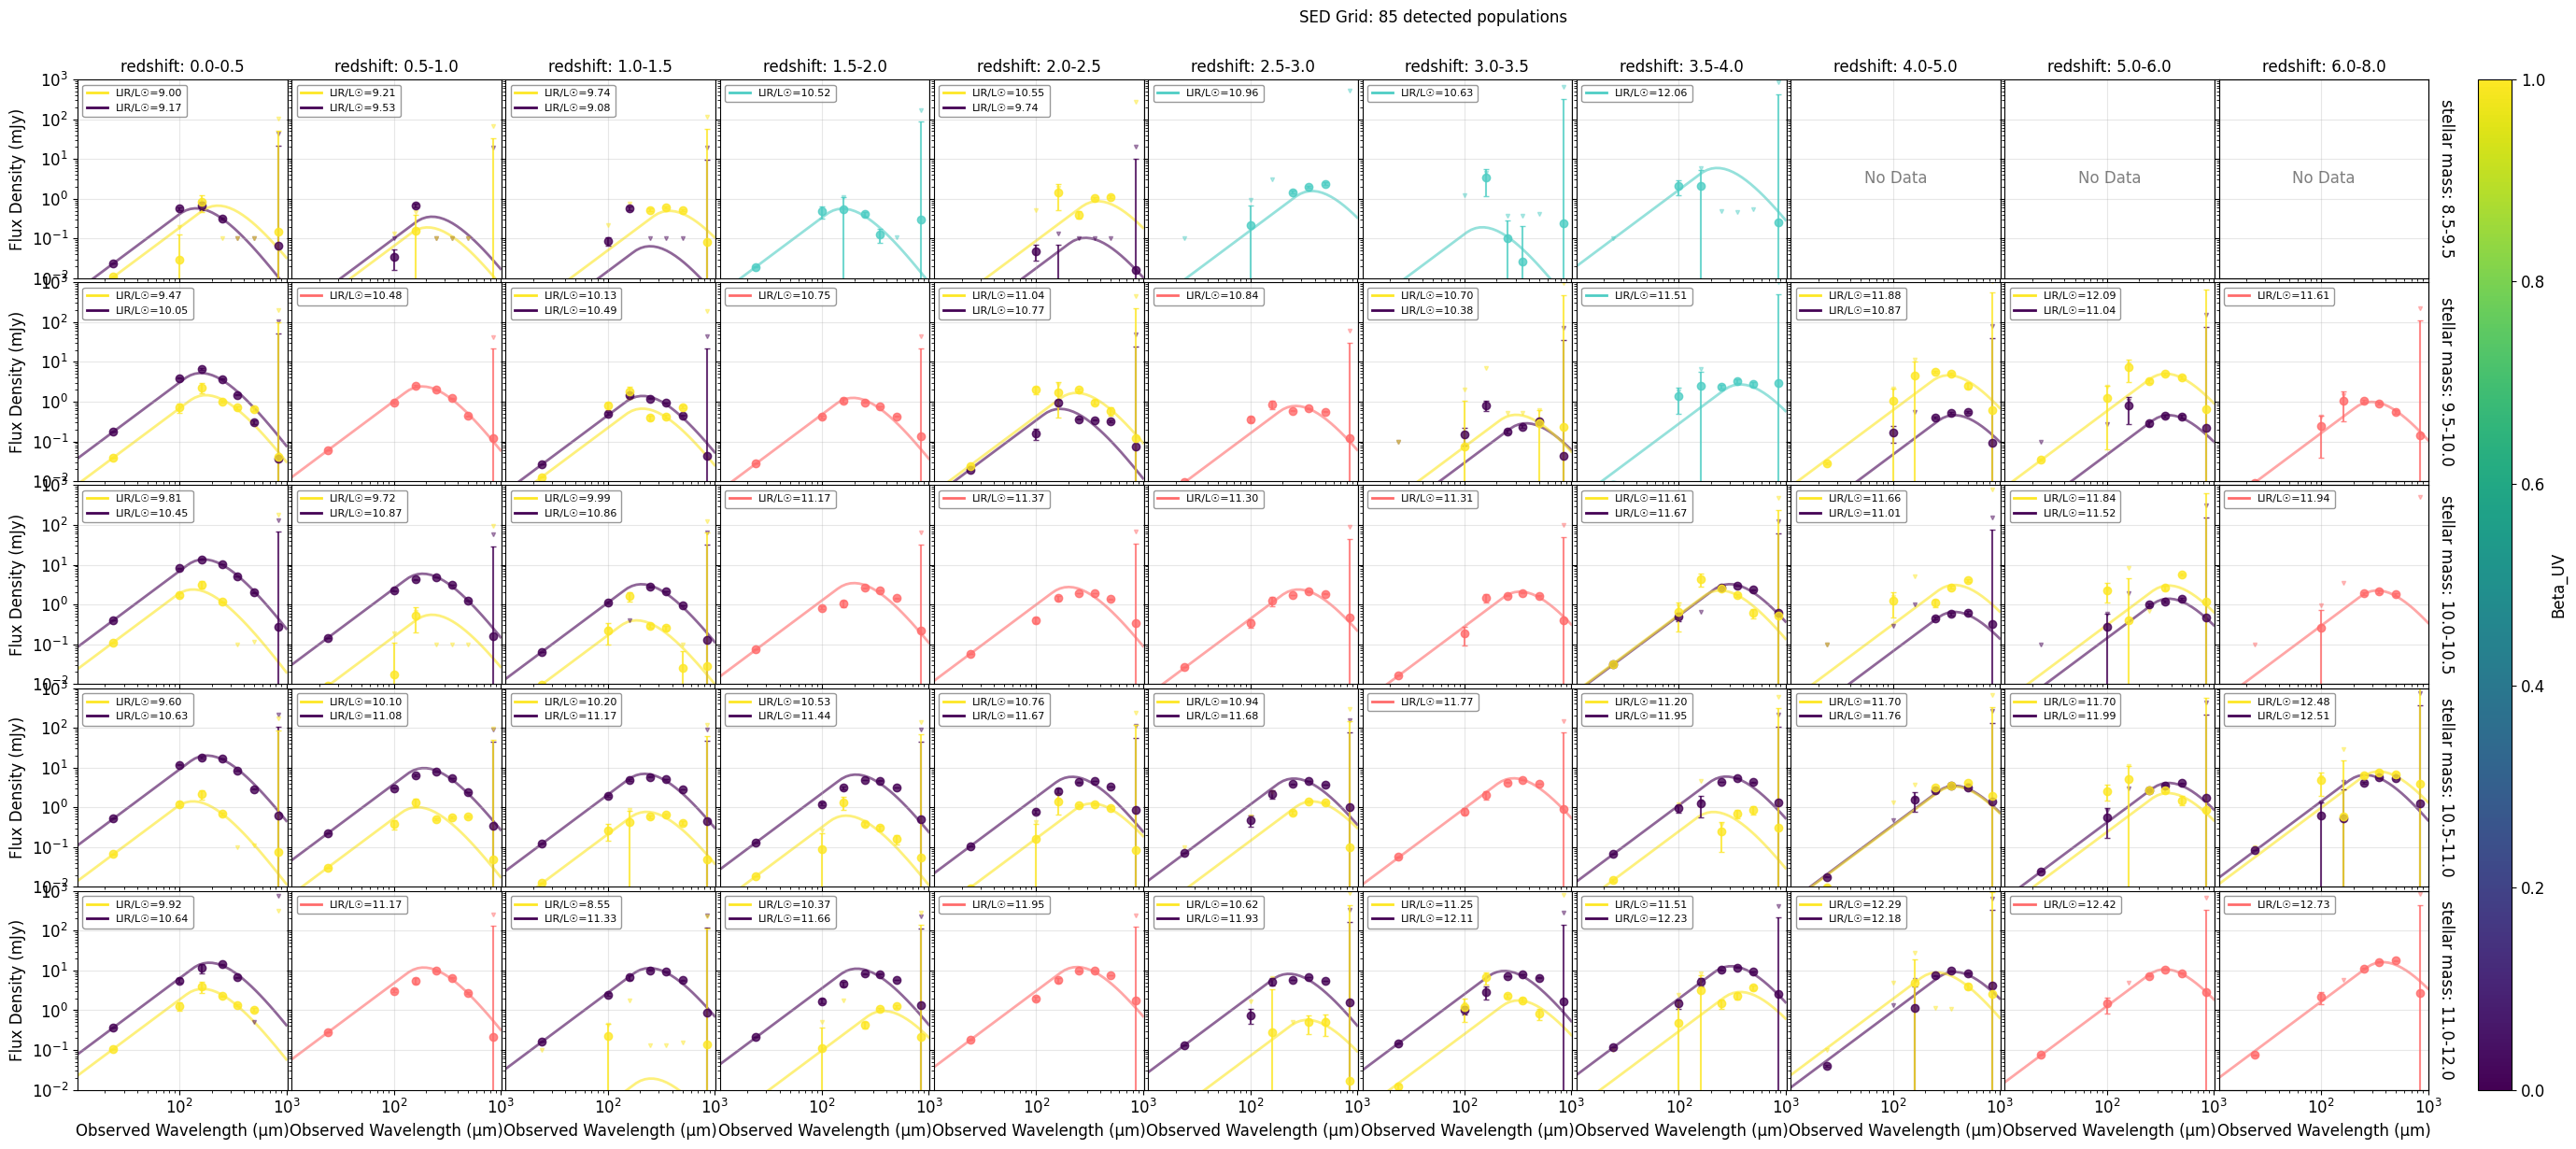

In [31]:
fig=create_sed_grid_plot(wrapper, save_path=f"/Users/mviero/Desktop/{output_file}")

📋 Available columns: ['population_id', 'n_sources', 'median_redshift', 'median_log_mass', 'n_bands', 'greybody_fit_success', 'dust_temperature_rest_frame_K', 'dust_temperature_observed_frame_K', 'dust_temperature_error_K', 'emissivity_index', 'chi2_reduced', 'total_ir_luminosity_lsun', 'total_ir_luminosity_error_lsun', 'dust_mass_msun', 'sfr_msun_yr', 'specific_sfr_yr']
📡 Available wavelengths: [ 24. 100. 160. 250. 350. 500. 850.] μm
📊 Map names: ['mips_24' 'pacs_green' 'pacs_red' 'spire_psw' 'spire_pmw' 'spire_plw'
 'scuba']
🔍 Using total_ir_luminosity_lsun for detection filter
✅ Found 85 detected populations
🏷️  Using population ID column: 'population_id'
🗂️  Detected binning dimensions: ['stellar_mass', 'redshift']
📐 Grid dimensions: redshift (x-axis) × stellar_mass (y-axis)
📊 Grid size: 11 × 5 = 55 panels
💾 Figure saved to: /Users/mviero/Desktop/sed_grid_nuvrj_simstack3.png


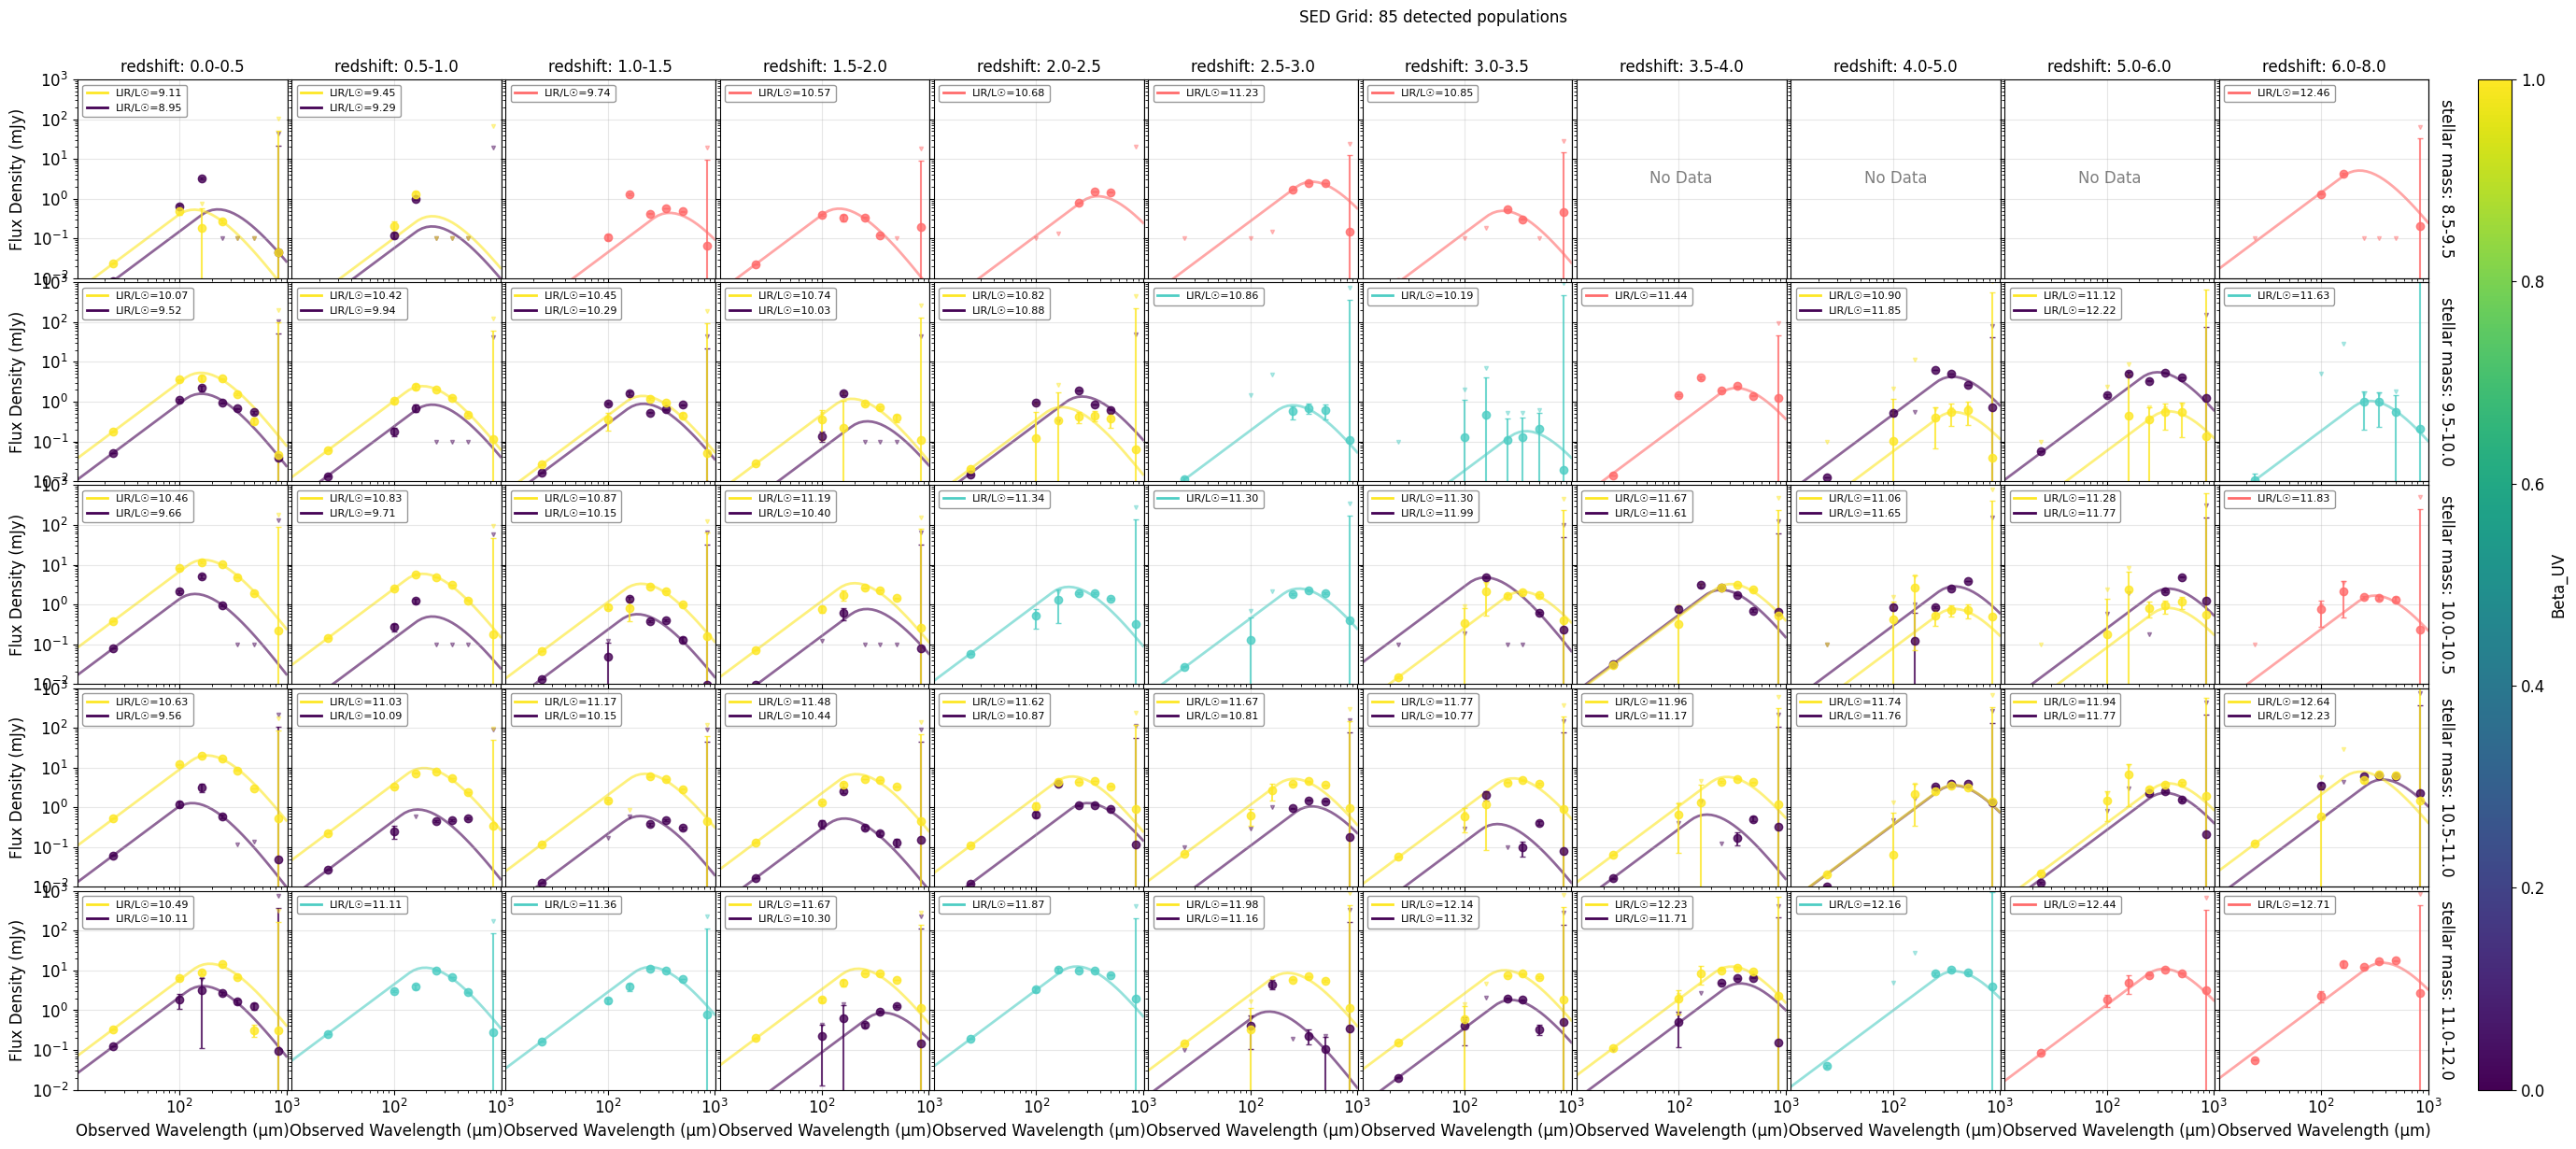

In [14]:
fig=create_sed_grid_plot(wrapper, save_path=f"/Users/mviero/Desktop/{output_file}")

In [32]:
# =============================================================================
# T_RF VS REDSHIFT PLOT FOR SIMSTACK4 RESULTS
# Extracts rest-frame dust temperatures and redshifts from wrapper results
# =============================================================================
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib.colors import LogNorm

def create_trf_redshift_plot(wrapper, 
                           color_by='l_ir',
                           size_by='n_sources', 
                           show_errors=True,
                           show_literature=True,
                           add_qt=False,
                           fit_data=True,
                           figsize=(10, 8),
                           save_path=None, xlim=None, ylim=None):
    """
    Create T_rf vs redshift plot from SimstackWrapper results
    
    Parameters:
    -----------
    wrapper : SimstackWrapper
        Wrapper object with stacking_results and processed_results
    color_by : str
        What to color points by: 'l_ir', 'stellar_mass', 'beta_uv', 'population_type', 'chi2'
    size_by : str  
        What to size points by: 'n_sources', 'l_ir', 'stellar_mass'
    show_errors : bool
        Whether to show error bars on temperature
    show_literature : bool
        Whether to show literature comparison lines
    add_qt : bool
        Whether to include quiescent galaxies (default: False, star-forming only)
    fit_data : bool
        Whether to fit and show power-law relation to the data
    figsize : tuple
        Figure size (width, height)
    save_path : str or Path or None
        Path to save the figure
    
    Returns:
    --------
    fig : matplotlib figure
        The created figure
    df_plot : pandas DataFrame
        The data used for plotting
    """
    
    # Check if we have the required data
    if not hasattr(wrapper, 'processed_results') or wrapper.processed_results is None:
        print("❌ No processed results found in wrapper")
        return None, None
    
    if not hasattr(wrapper.processed_results, 'sed_results'):
        print("❌ No SED results found in processed results")
        return None, None
    
    print("✅ Found processed results with SED data")
    
    # Extract data from SED results
    data_list = []
    
    for pop_id, sed_result in wrapper.processed_results.sed_results.items():
        # Skip if no greybody fit or no temperature
        if not sed_result.greybody_fit_success:
            continue
            
        if sed_result.dust_temperature_rest_frame is None:
            continue
            
        # Get basic data
        row = {
            'population_id': pop_id,
            'redshift': sed_result.median_redshift,
            'T_rest_frame': sed_result.dust_temperature_rest_frame,
            'T_observed_frame': sed_result.dust_temperature_observed_frame,
            'T_error': sed_result.dust_temperature_error,
            'n_sources': sed_result.n_sources,
            'stellar_mass': sed_result.median_mass,
            'chi2_reduced': sed_result.chi2_reduced,
            'beta': sed_result.emissivity_index,
            'amplitude': sed_result.amplitude,
        }
        
        # Get derived quantities
        if pop_id in wrapper.processed_results.derived_quantities:
            derived = wrapper.processed_results.derived_quantities[pop_id]
            row['l_ir'] = derived.total_ir_luminosity
            row['l_ir_error'] = derived.total_ir_luminosity_error
            row['sfr'] = derived.star_formation_rate
            row['dust_mass'] = derived.dust_mass
        else:
            row['l_ir'] = 0
            row['l_ir_error'] = 0
            row['sfr'] = 0
            row['dust_mass'] = None
        
        # Parse population type from ID
        if 'split_0' in pop_id:
            row['population_type'] = 'Star-forming'
            row['pop_type_code'] = 0
        elif 'split_1' in pop_id:
            row['population_type'] = 'Quiescent'
            row['pop_type_code'] = 1
        else:
            row['population_type'] = 'Unknown'
            row['pop_type_code'] = -1
        
        # Extract other bin information
        try:
            parts = pop_id.split('__')
            for part in parts:
                if 'stellar_mass' in part or 'mass' in part:
                    elements = part.split('_')
                    if len(elements) >= 3:
                        try:
                            mass_min = float(elements[-2])
                            mass_max = float(elements[-1])
                            row['mass_bin_center'] = (mass_min + mass_max) / 2
                        except ValueError:
                            pass
                elif 'redshift' in part or '_z_' in part:
                    elements = part.split('_')
                    if len(elements) >= 3:
                        try:
                            z_min = float(elements[-2])
                            z_max = float(elements[-1])
                            row['z_bin_center'] = (z_min + z_max) / 2
                        except ValueError:
                            pass
        except:
            pass
        
        data_list.append(row)
    
    if not data_list:
        print("❌ No valid temperature measurements found")
        return None, None
    
    # Create DataFrame
    df_plot = pd.DataFrame(data_list)
    
    # Filter by population type if requested
    if not add_qt:
        # Keep only star-forming galaxies (default behavior)
        initial_count = len(df_plot)
        df_plot = df_plot[df_plot['pop_type_code'] == 0].copy()
        quiescent_count = initial_count - len(df_plot)
        if quiescent_count > 0:
            print(f"🔍 Filtered out {quiescent_count} quiescent galaxies (use add_qt=True to include)")
    
    print(f"📊 Found {len(df_plot)} populations with valid T_rest measurements")
    if len(df_plot) == 0:
        print("❌ No data remaining after filtering")
        return None, None
        
    print(f"   Redshift range: {df_plot['redshift'].min():.2f} - {df_plot['redshift'].max():.2f}")
    print(f"   T_rest range: {df_plot['T_rest_frame'].min():.1f} - {df_plot['T_rest_frame'].max():.1f} K")
    
    # Create the plot
    fig, ax = plt.subplots(1, 1, figsize=figsize)
    
    # Set up coloring
    if color_by == 'l_ir':
        color_data = np.log10(df_plot['l_ir'].replace(0, np.nan))
        color_label = 'log₁₀(L_IR/L☉)'
        cmap = 'plasma'
        vmin, vmax = None, None
    elif color_by == 'stellar_mass':
        color_data = df_plot['stellar_mass']
        color_label = 'log₁₀(M*/M☉)'
        cmap = 'viridis'
        vmin, vmax = None, None
    elif color_by == 'population_type':
        color_data = df_plot['pop_type_code']
        color_label = 'Population Type'
        cmap = 'RdBu'
        vmin, vmax = -0.5, 1.5
    elif color_by == 'chi2':
        color_data = df_plot['chi2_reduced']
        color_label = 'χ²_reduced'
        cmap = 'coolwarm'
        vmin, vmax = 0.5, 2.0
    elif color_by == 'beta_uv':
        # Try to get beta_UV from population manager if available
        color_data = df_plot['beta'] 
        color_label = 'β (emissivity index)'
        cmap = 'coolwarm'
        vmin, vmax = 1.0, 2.5
    else:
        color_data = 'blue'
        color_label = None
        cmap = None
        vmin, vmax = None, None
    
    # Set up sizing
    if size_by == 'n_sources':
        size_data = df_plot['n_sources']
        # Scale sizes: min=20, max=200
        size_min, size_max = 20, 200
        sizes = size_min + (size_max - size_min) * (size_data - size_data.min()) / (size_data.max() - size_data.min())
        size_label = 'N_sources'
    elif size_by == 'l_ir':
        size_data = np.log10(df_plot['l_ir'].replace(0, 1e8))
        size_min, size_max = 20, 200
        sizes = size_min + (size_max - size_min) * (size_data - size_data.min()) / (size_data.max() - size_data.min())
        size_label = 'log₁₀(L_IR/L☉)'
    elif size_by == 'stellar_mass':
        size_data = df_plot['stellar_mass']
        size_min, size_max = 20, 200
        sizes = size_min + (size_max - size_min) * (size_data - size_data.min()) / (size_data.max() - size_data.min())
        size_label = 'log₁₀(M*/M☉)'
    else:
        sizes = 50
        size_label = None
    
    # Make the scatter plot
    if show_errors and 'T_error' in df_plot.columns:
        # Plot with error bars
        if isinstance(color_data, str):
            # Single color
            scatter = ax.errorbar(df_plot['redshift'], df_plot['T_rest_frame'], 
                                yerr=df_plot['T_error'],
                                fmt='o', color=color_data, markersize=8, 
                                capsize=3, alpha=0.7, elinewidth=1)
        else:
            # Color-coded points with error bars (more complex)
            scatter = ax.scatter(df_plot['redshift'], df_plot['T_rest_frame'], 
                               c=color_data, s=sizes, alpha=0.7, 
                               cmap=cmap, vmin=vmin, vmax=vmax, 
                               edgecolors='black', linewidth=0.5)
            
            # Add error bars separately
            ax.errorbar(df_plot['redshift'], df_plot['T_rest_frame'], 
                       yerr=df_plot['T_error'],
                       fmt='none', color='gray', alpha=0.3, 
                       capsize=2, elinewidth=0.8)
    else:
        # Plot without error bars
        if isinstance(color_data, str):
            scatter = ax.scatter(df_plot['redshift'], df_plot['T_rest_frame'], 
                               s=sizes, color=color_data, alpha=0.7,
                               edgecolors='black', linewidth=0.5)
        else:
            scatter = ax.scatter(df_plot['redshift'], df_plot['T_rest_frame'], 
                               c=color_data, s=sizes, alpha=0.7, 
                               cmap=cmap, vmin=vmin, vmax=vmax,
                               edgecolors='black', linewidth=0.5)
    
    # Add colorbar if needed
    if not isinstance(color_data, str) and color_label:
        cbar = plt.colorbar(scatter, ax=ax, shrink=0.8)
        cbar.set_label(color_label, fontsize=12)
        
        # Special handling for population type
        if color_by == 'population_type':
            cbar.set_ticks([0, 1])
            cbar.set_ticklabels(['Star-forming', 'Quiescent'])
    
    # Add literature relations if requested
    if show_literature:
        z_lit = np.linspace(0, 6, 100)
        
        # Casey et al. 2018: T_d = 25 * (1+z)^0.36 K
        T_casey = 25 * (1 + z_lit)**0.36
        ax.plot(z_lit, T_casey, '--', color='red', linewidth=2, 
               label='Casey+18: T∝(1+z)^0.36', alpha=0.8)
        
        # Magnelli et al. 2014: T_d = 32.9 + 4.6*z K  
        T_magnelli = 32.9 + 4.6 * z_lit
        ax.plot(z_lit, T_magnelli, '--', color='orange', linewidth=2,
               label='Magnelli+14: T=32.9+4.6z', alpha=0.8)
        
        # Schreiber et al. 2018: T_d ≈ 24 * (1+z)^0.32 K
        T_schreiber = 24 * (1 + z_lit)**0.32
        ax.plot(z_lit, T_schreiber, '--', color='green', linewidth=2,
               label='Schreiber+18: T∝(1+z)^0.32', alpha=0.8)
        
        # Viero et al. 2022: Near exponential increase reaching ~100K at z~7
        # From abstract: "increase of dust temperature with redshift, reaching 100±12 K at z ~ 7"
        # This suggests a steep rise. Let's approximate as T_d = 25 * (1+z)^0.6
        T_viero = 25 * (1 + z_lit)**0.6
        ax.plot(z_lit, T_viero, '--', color='purple', linewidth=2,
               label='Viero+22: T∝(1+z)^0.6', alpha=0.8)
    
    # Fit data if requested
    if fit_data and len(df_plot) >= 3:
        try:
            from scipy.optimize import curve_fit
            
            # Define fitting functions
            def power_law(z, T0, alpha):
                return T0 * (1 + z)**alpha
            
            def linear_law(z, T0, slope):
                return T0 + slope * z
            
            # Get data for fitting
            z_data = df_plot['redshift'].values
            T_data = df_plot['T_rest_frame'].values
            T_errors = df_plot['T_error'].values if 'T_error' in df_plot.columns else None
            
            # Fit power law: T = T0 * (1+z)^alpha
            try:
                if T_errors is not None and np.any(T_errors > 0):
                    popt_power, pcov_power = curve_fit(power_law, z_data, T_data, 
                                                     sigma=T_errors, p0=[25, 0.4],
                                                     bounds=([10, 0], [50, 2]))
                else:
                    popt_power, pcov_power = curve_fit(power_law, z_data, T_data, 
                                                     p0=[25, 0.4],
                                                     bounds=([10, 0], [50, 2]))
                
                T0_power, alpha_power = popt_power
                T0_err, alpha_err = np.sqrt(np.diag(pcov_power))
                
                # Calculate R-squared
                T_pred_power = power_law(z_data, T0_power, alpha_power)
                ss_res_power = np.sum((T_data - T_pred_power) ** 2)
                ss_tot = np.sum((T_data - np.mean(T_data)) ** 2)
                r2_power = 1 - (ss_res_power / ss_tot)
                
                # Plot fit
                z_fit = np.linspace(z_data.min(), z_data.max() * 1.1, 100)
                T_fit_power = power_law(z_fit, T0_power, alpha_power)
                ax.plot(z_fit, T_fit_power, '-', color='black', linewidth=3, alpha=0.8,
                       label=f'This work: T={T0_power:.1f}(1+z)^{alpha_power:.2f} (R²={r2_power:.2f})')
                
                print(f"🔬 Power-law fit: T = {T0_power:.1f}±{T0_err:.1f} × (1+z)^{alpha_power:.2f}±{alpha_err:.2f}")
                print(f"   R² = {r2_power:.3f}")
                
            except Exception as e:
                print(f"⚠️  Power-law fit failed: {e}")
            
            # Also try linear fit: T = T0 + slope*z
            try:
                if T_errors is not None and np.any(T_errors > 0):
                    popt_linear, pcov_linear = curve_fit(linear_law, z_data, T_data, 
                                                       sigma=T_errors, p0=[30, 5])
                else:
                    popt_linear, pcov_linear = curve_fit(linear_law, z_data, T_data, 
                                                       p0=[30, 5])
                
                T0_linear, slope_linear = popt_linear
                T0_linear_err, slope_linear_err = np.sqrt(np.diag(pcov_linear))
                
                # Calculate R-squared
                T_pred_linear = linear_law(z_data, T0_linear, slope_linear)
                ss_res_linear = np.sum((T_data - T_pred_linear) ** 2)
                r2_linear = 1 - (ss_res_linear / ss_tot)
                
                print(f"🔬 Linear fit: T = {T0_linear:.1f}±{T0_linear_err:.1f} + {slope_linear:.1f}±{slope_linear_err:.1f}×z")
                print(f"   R² = {r2_linear:.3f}")
                
                # Add best fit info to legend
                if r2_power > r2_linear:
                    print(f"📈 Power-law fit is better (R² = {r2_power:.3f} vs {r2_linear:.3f})")
                else:
                    print(f"📈 Linear fit is better (R² = {r2_linear:.3f} vs {r2_power:.3f})")
                    
            except Exception as e:
                print(f"⚠️  Linear fit failed: {e}")
                
        except ImportError:
            print("⚠️  scipy not available for fitting")
        except Exception as e:
            print(f"⚠️  Fitting failed: {e}")
    
    # Formatting
    ax.set_xlabel('Redshift', fontsize=14)
    ax.set_ylabel('Rest-frame Dust Temperature (K)', fontsize=14)
    ax.tick_params(axis='both', which='major', labelsize=12)
    ax.grid(True, alpha=0.3)
    
    # Set reasonable limits
    if xlim is not None:
        ax.set_xlim(xlim)
    else:
        ax.set_xlim(0, df_plot['redshift'].max() * 1.1)
    if ylim is not None:
        ax.set_ylim(ylim)
    else:
        ax.set_ylim(df_plot['T_rest_frame'].min() * 0.9, 
                    min(df_plot['T_rest_frame'].max() * 1.1, 80))
    
    # Title and legend
    title = f'Rest-frame Dust Temperature vs Redshift'
    if len(df_plot) > 1:
        title += f' ({len(df_plot)} populations)'
    ax.set_title(title, fontsize=16, pad=20)
    
    if show_literature:
        ax.legend(loc='upper left', fontsize=10, framealpha=0.8)
    
    # Add size legend if varying sizes
    if size_label and not isinstance(sizes, (int, float)):
        # Create size legend
        size_legend_values = [size_data.min(), size_data.median(), size_data.max()]
        size_legend_sizes = [size_min, (size_min + size_max)/2, size_max]
        size_legend_labels = [f'{v:.0f}' if size_by == 'n_sources' else f'{v:.1f}' 
                             for v in size_legend_values]
        
        # Add size legend as text
        ax.text(0.02, 0.98, f'Marker size: {size_label}', 
               transform=ax.transAxes, fontsize=10, 
               verticalalignment='top',
               bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
    
    plt.tight_layout()
    
    # Save if requested
    if save_path is not None:
        try:
            from pathlib import Path
            save_path = Path(save_path)
            save_path.parent.mkdir(parents=True, exist_ok=True)
            
            dpi = 300 if save_path.suffix.lower() in ['.png', '.jpg', '.jpeg'] else 150
            plt.savefig(save_path, dpi=dpi, bbox_inches='tight', 
                       facecolor='white', edgecolor='none')
            print(f"💾 Figure saved to: {save_path}")
             
        except Exception as e:
            print(f"⚠️  Could not save figure: {e}")
    
    return fig, df_plot


def create_temperature_evolution_plot(wrapper, 
                                    split_by_type=True,
                                    show_individual=True,
                                    show_literature=True,
                                    add_qt=False,
                                    fit_data=True,
                                    figsize=(12, 8),
                                    save_path=None):
    """
    Create a comprehensive temperature evolution plot with multiple panels
    
    Parameters:
    -----------
    wrapper : SimstackWrapper
        Wrapper object with results
    split_by_type : bool
        Whether to separate star-forming and quiescent galaxies
    show_individual : bool
        Whether to show individual population points
    show_literature : bool
        Whether to show literature comparison
    add_qt : bool
        Whether to include quiescent galaxies (default: False)
    fit_data : bool
        Whether to fit relations to the data
    figsize : tuple
        Figure size
    save_path : str or Path or None
        Path to save figure
    """
    
    # Get data using the main function
    fig_temp, df_plot = create_trf_redshift_plot(wrapper, color_by='population_type', 
                                               show_errors=True, show_literature=False,
                                               add_qt=add_qt, fit_data=False)
    plt.close(fig_temp)  # Close the temporary figure
    
    if df_plot is None:
        print("❌ No data available for temperature evolution plot")
        return None, None
    
    # Create comprehensive plot
    if split_by_type and 'pop_type_code' in df_plot.columns:
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=figsize, sharey=True)
        axes = [ax1, ax2]
        
        # Separate by population type
        sf_data = df_plot[df_plot['pop_type_code'] == 0]  # Star-forming
        q_data = df_plot[df_plot['pop_type_code'] == 1]   # Quiescent
        
        datasets = [sf_data, q_data]
        colors = ['#FF6B6B', '#4ECDC4']  # Red for SF, Teal for Q
        labels = ['Star-forming', 'Quiescent']
        
    else:
        fig, ax1 = plt.subplots(1, 1, figsize=figsize)
        axes = [ax1]
        datasets = [df_plot]
        colors = ['#45B7D1']
        labels = ['All galaxies']
    
    # Plot each dataset
    for ax, data, color, label in zip(axes, datasets, colors, labels):
        if len(data) == 0:
            ax.text(0.5, 0.5, f'No {label.lower()} data', 
                   ha='center', va='center', transform=ax.transAxes)
            continue
        
        # Individual points
        if show_individual:
            sizes = 50 + 150 * (data['n_sources'] - data['n_sources'].min()) / (data['n_sources'].max() - data['n_sources'].min())
            
            scatter = ax.scatter(data['redshift'], data['T_rest_frame'], 
                               s=sizes, color=color, alpha=0.7,
                               edgecolors='black', linewidth=0.5,
                               label=f'{label} (N={len(data)})')
            
            # Error bars
            if 'T_error' in data.columns:
                ax.errorbar(data['redshift'], data['T_rest_frame'], 
                           yerr=data['T_error'],
                           fmt='none', color='gray', alpha=0.3, 
                           capsize=2, elinewidth=0.8)
        
        # Bin and plot trends if enough data
        if len(data) >= 4:
            # Bin by redshift
            z_bins = np.linspace(data['redshift'].min(), data['redshift'].max(), 4)
            z_centers = []
            T_means = []
            T_errors = []
            
            for i in range(len(z_bins)-1):
                mask = (data['redshift'] >= z_bins[i]) & (data['redshift'] < z_bins[i+1])
                if np.sum(mask) > 0:
                    z_centers.append((z_bins[i] + z_bins[i+1]) / 2)
                    T_means.append(data.loc[mask, 'T_rest_frame'].mean())
                    T_errors.append(data.loc[mask, 'T_rest_frame'].std() / np.sqrt(np.sum(mask)))
            
            if len(z_centers) > 1:
                ax.errorbar(z_centers, T_means, yerr=T_errors,
                           fmt='s-', color=color, markersize=8, linewidth=2,
                           capsize=4, label=f'{label} (binned trend)')
        
        # Literature comparison
        if show_literature:
            z_lit = np.linspace(0, 6, 100)
            
            # Casey et al. 2018
            T_casey = 25 * (1 + z_lit)**0.36
            ax.plot(z_lit, T_casey, '--', color='gray', linewidth=1.5, 
                   alpha=0.8, label='Casey+18' if ax == axes[0] else '')
            
            # Magnelli et al. 2014
            T_magnelli = 32.9 + 4.6 * z_lit
            ax.plot(z_lit, T_magnelli, ':', color='gray', linewidth=1.5,
                   alpha=0.8, label='Magnelli+14' if ax == axes[0] else '')
            
            # Viero et al. 2022
            T_viero = 25 * (1 + z_lit)**0.6
            ax.plot(z_lit, T_viero, '-', color='purple', linewidth=1.5,
                   alpha=0.8, label='Viero+22' if ax == axes[0] else '')
        
        # Formatting
        ax.set_xlabel('Redshift', fontsize=14)
        if ax == axes[0]:
            ax.set_ylabel('Rest-frame Dust Temperature (K)', fontsize=14)
        ax.set_title(f'{label}', fontsize=14)
        ax.tick_params(axis='both', which='major', labelsize=12)
        ax.grid(True, alpha=0.3)
        ax.legend(fontsize=10)
        
        # Set limits
        if len(data) > 0:
            ax.set_xlim(0, max(6, data['redshift'].max() * 1.1))
            ax.set_ylim(15, 60)
    
    plt.tight_layout()
    
    # Save if requested
    if save_path is not None:
        try:
            from pathlib import Path
            save_path = Path(save_path)
            save_path.parent.mkdir(parents=True, exist_ok=True)
            
            dpi = 300 if save_path.suffix.lower() in ['.png', '.jpg', '.jpeg'] else 150
            plt.savefig(save_path, dpi=dpi, bbox_inches='tight', 
                       facecolor='white', edgecolor='none')
            print(f"💾 Temperature evolution plot saved to: {save_path}")
             
        except Exception as e:
            print(f"⚠️  Could not save figure: {e}")
    
    return fig, df_plot


# Usage example:
def plot_temperature_evolution_example(wrapper, add_qt=False):
    """
    Example usage of the temperature plotting functions
    """
    print("Creating T_rf vs redshift plots...")
    
    # Basic plot colored by L_IR (star-forming only by default)
    fig1, df1 = create_trf_redshift_plot(wrapper, 
                                       color_by='l_ir',
                                       size_by='n_sources',
                                       show_errors=True,
                                       add_qt=add_qt,
                                       fit_data=True,
                                       save_path='temperature_vs_redshift_basic.png')
    
    # Plot colored by population type (if including quiescent)
    if add_qt:
        fig2, df2 = create_trf_redshift_plot(wrapper,
                                           color_by='population_type', 
                                           size_by='stellar_mass',
                                           add_qt=True,
                                           fit_data=True,
                                           save_path='temperature_vs_redshift_by_type.png')
    else:
        fig2, df2 = create_trf_redshift_plot(wrapper,
                                           color_by='stellar_mass', 
                                           size_by='n_sources',
                                           add_qt=False,
                                           fit_data=True,
                                           save_path='temperature_vs_redshift_sf_only.png')
    
    # Comprehensive evolution plot
    fig3, df3 = create_temperature_evolution_plot(wrapper,
                                                split_by_type=add_qt,
                                                show_individual=True,
                                                show_literature=True,
                                                add_qt=add_qt,
                                                fit_data=True,
                                                save_path='temperature_evolution_comprehensive.png')
    
    print("✅ Temperature evolution plots created!")
    
    return fig1, fig2, fig3, df1

✅ Found processed results with SED data
🔍 Filtered out 38 quiescent galaxies (use add_qt=True to include)
📊 Found 47 populations with valid T_rest measurements
   Redshift range: 0.33 - 6.44
   T_rest range: 22.6 - 86.5 K
🔬 Power-law fit: T = 20.8±0.7 × (1+z)^0.54±0.03
   R² = 0.726
🔬 Linear fit: T = 23.5±0.8 + 6.3±0.3×z
   R² = 0.727
📈 Linear fit is better (R² = 0.727 vs 0.726)
💾 Figure saved to: trf_vs_z.png


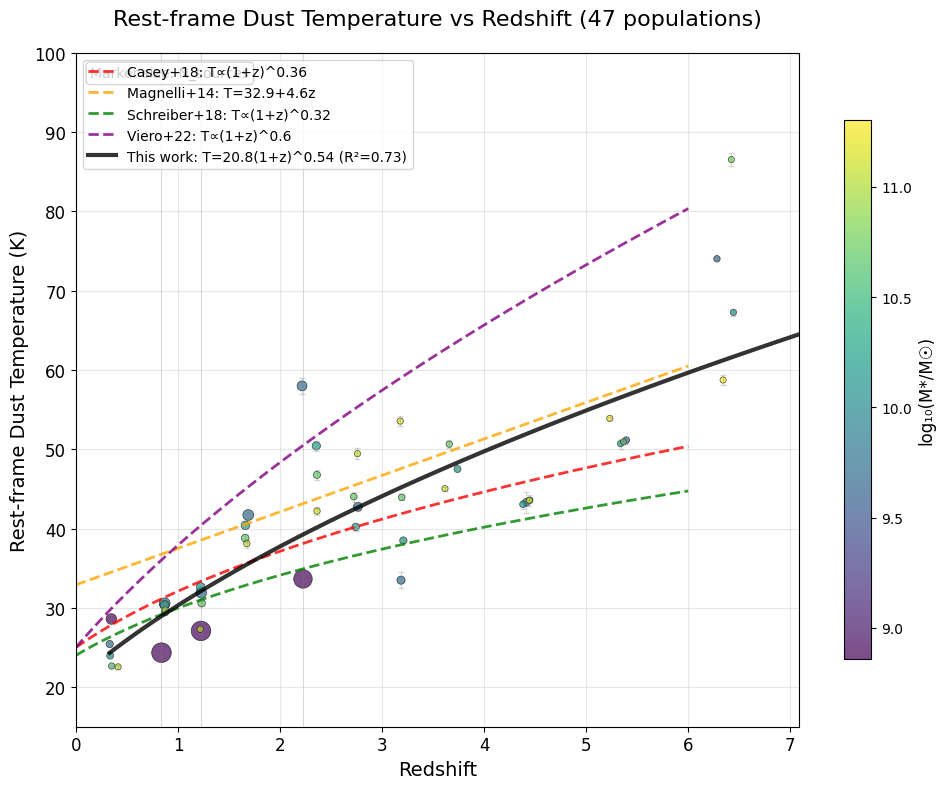

In [33]:
# Basic plot colored by L_IR
fig1, df = create_trf_redshift_plot(wrapper, 
                                  color_by='stellar_mass',
                                  size_by='n_sources',
                                  show_errors=True,
                                  save_path='trf_vs_z.png',
                                  ylim=[15,100])


✅ Found processed results with SED data
🔍 Filtered out 38 quiescent galaxies (use add_qt=True to include)
📊 Found 47 populations with valid T_rest measurements
   Redshift range: 0.33 - 6.44
   T_rest range: 22.6 - 86.5 K
🔬 Power-law fit: T = 20.8±0.7 × (1+z)^0.54±0.03
   R² = 0.644
🔬 Linear fit: T = 23.5±0.8 + 6.3±0.3×z
   R² = 0.631
📈 Power-law fit is better (R² = 0.644 vs 0.631)
💾 Figure saved to: trf_vs_z.png


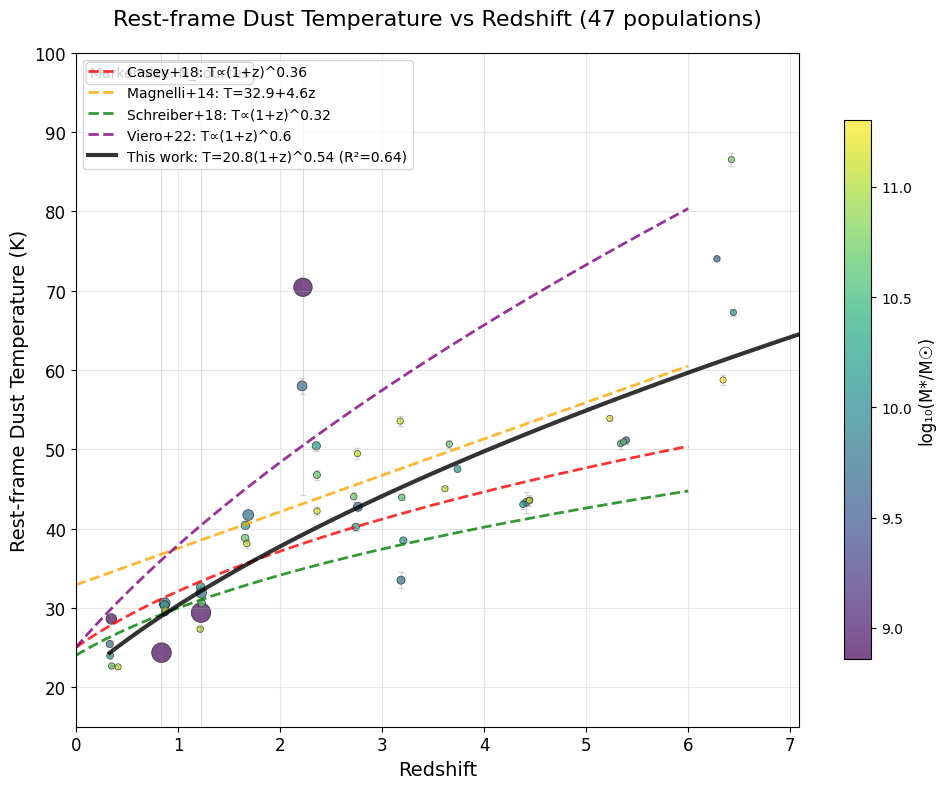

In [21]:
# Basic plot colored by L_IR
fig1, df = create_trf_redshift_plot(wrapper, 
                                  color_by='stellar_mass',
                                  size_by='n_sources',
                                  show_errors=True,
                                  save_path='trf_vs_z.png',
                                  ylim=[15,100])


✅ Found processed results with SED data
🔍 Filtered out 38 quiescent galaxies (use add_qt=True to include)
📊 Found 47 populations with valid T_rest measurements
   Redshift range: 0.33 - 6.44
   T_rest range: 22.6 - 86.5 K
🔬 Power-law fit: T = 20.8±0.7 × (1+z)^0.54±0.03
   R² = 0.727
🔬 Linear fit: T = 23.5±0.8 + 6.3±0.3×z
   R² = 0.727
📈 Linear fit is better (R² = 0.727 vs 0.727)
💾 Figure saved to: trf_vs_z.png


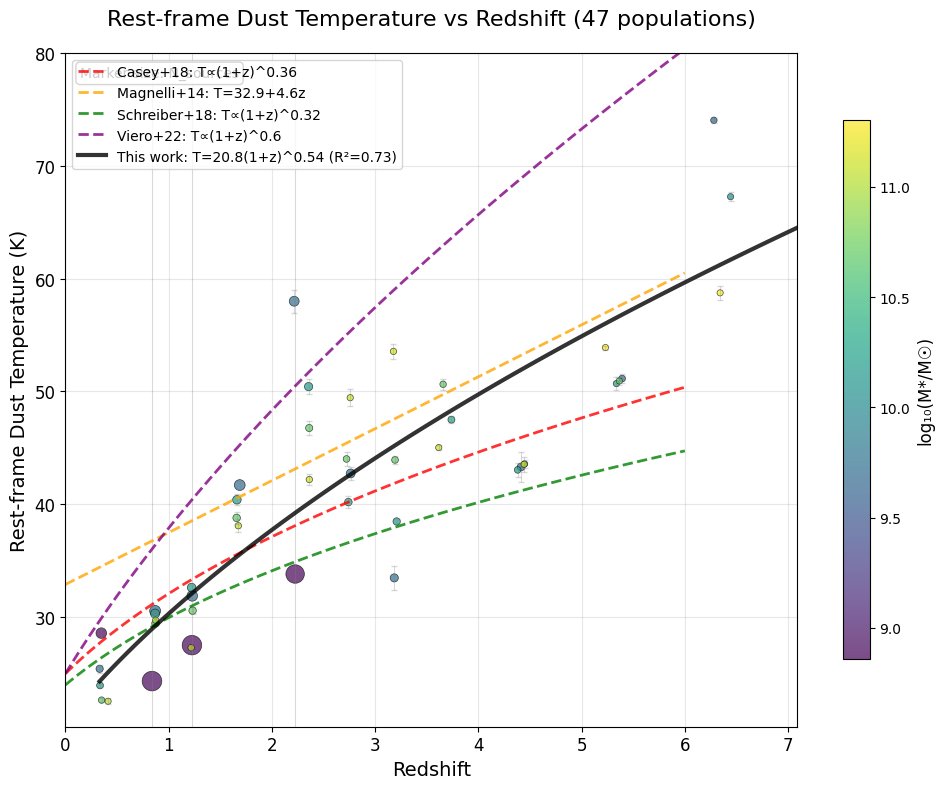

In [14]:
# Basic plot colored by L_IR
fig1, df = create_trf_redshift_plot(wrapper, 
                                  color_by='stellar_mass',
                                  size_by='n_sources',
                                  show_errors=True,
                                  save_path='trf_vs_z.png')


✅ Found processed results with SED data
📊 Found 85 populations with valid T_rest measurements
   Redshift range: 0.33 - 6.46
   T_rest range: 17.3 - 114.8 K


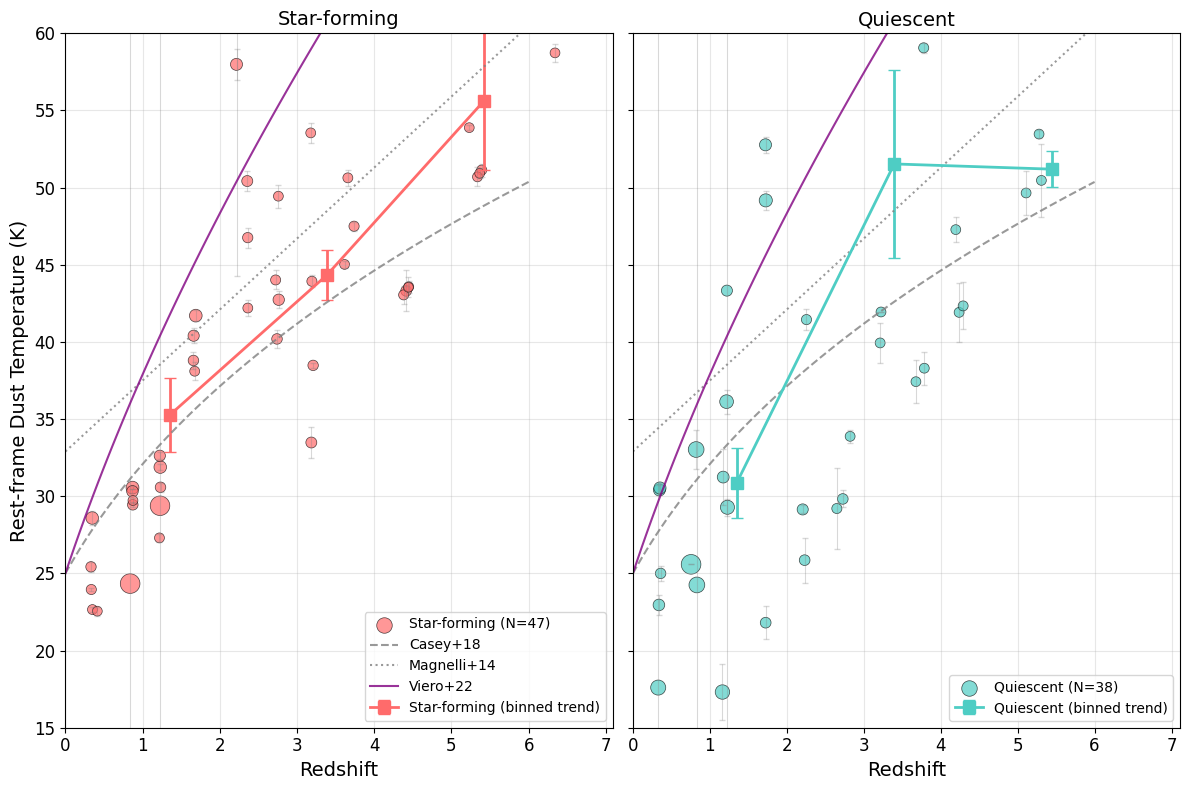

In [22]:
# Comprehensive evolution plot
fig3, df = create_temperature_evolution_plot(wrapper,
                                           split_by_type=True,
                                             add_qt=True,
                                           show_literature=True)

In [34]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.colors import LogNorm
import seaborn as sns

def plot_sfr_vs_redshift_by_mass(wrapper, save_path=None, figsize=(10, 8), 
                                plot_specific_sfr=False):
    """
    Create SFR vs redshift plot colored by stellar mass (similar to Viero+2022 Fig 3)
    
    Parameters:
    -----------
    wrapper : SimstackWrapper
        Wrapper with processed results
    save_path : str or None
        Path to save figure
    figsize : tuple
        Figure size (width, height)
    plot_specific_sfr : bool
        If True, plot specific SFR (sSFR) instead of SFR
    """
    
    # Check if we have processed results
    if not wrapper.processed_results:
        print("❌ No processed results found. Running analysis...")
        wrapper.run_analysis_only()
    
    # Get population summary
    try:
        summary_df = wrapper.processed_results.get_population_summary()
        print(f"📊 Found {len(summary_df)} populations in summary")
    except Exception as e:
        print(f"❌ Could not get population summary: {e}")
        return None
    
    # Filter for star-forming galaxies only
    # Look for populations with 'split_0' (assuming this indicates star-forming)
    sf_mask = summary_df['population_id'].str.contains('split_0', na=False)
    
    if not sf_mask.any():
        print("⚠️  No star-forming populations found (looking for 'split_0')")
        print("Available population IDs:")
        for pid in summary_df['population_id'].head(10):
            print(f"  {pid}")
        # Use all populations if no split found
        sf_mask = pd.Series([True] * len(summary_df))
        print("Using all populations instead...")
    
    sf_df = summary_df[sf_mask].copy()
    print(f"🌟 Found {len(sf_df)} star-forming populations")
    
    # Filter for detections (positive SFR and L_IR) - FIXED LOGIC
    if plot_specific_sfr:
        detection_mask = (
            (sf_df['sfr_msun_yr'] > 0) & 
            (sf_df['total_ir_luminosity_lsun'] > 0) &
            (sf_df['n_sources'] > 0) &
            (sf_df['specific_sfr_yr'] > 0)
        )
    else:
        detection_mask = (
            (sf_df['sfr_msun_yr'] > 0) & 
            (sf_df['total_ir_luminosity_lsun'] > 0) &
            (sf_df['n_sources'] > 0)
        )
    
    sf_detected = sf_df[detection_mask].copy()
    print(f"🔍 Found {len(sf_detected)} detected star-forming populations")
    
    if len(sf_detected) == 0:
        print("❌ No detected star-forming populations found")
        return None
    
    # Extract data for plotting
    redshifts = sf_detected['median_redshift'].values
    
    # Choose between SFR and sSFR
    if plot_specific_sfr:
        y_values = sf_detected['specific_sfr_yr'].values  * 1e9  # sSFR in yr^-1
        y_label = 'Specific Star Formation Rate [yr⁻¹]'
        y_title = 'Specific Star Formation Rate vs Redshift'
        y_lim = (1e-2, 2e1)  # Typical sSFR range
        save_suffix = 'ssfr'
    else:
        y_values = sf_detected['sfr_msun_yr'].values  # SFR in M_sun/yr
        y_label = 'Star Formation Rate [M☉ yr⁻¹]'
        y_title = 'Star Formation Rate vs Redshift'
        y_lim = (1, 1000)  # Typical SFR range
        save_suffix = 'sfr'
    
    stellar_masses = 10**sf_detected['median_log_mass'].values  # Convert from log
    n_sources = sf_detected['n_sources'].values
    
    # Create the plot
    fig, ax = plt.subplots(1, 1, figsize=figsize)
    
    # Create scatter plot colored by stellar mass
    scatter = ax.scatter(
        redshifts, y_values, 
        c=stellar_masses, 
        s=60 + 60, #n_sources/20,  # Size scales with number of sources
        cmap='plasma',  # Good colormap for stellar mass
        norm=LogNorm(vmin=1e9, vmax=1e12),  # Typical stellar mass range
        alpha=0.8,
        edgecolors='white',
        linewidth=0.5
    )
    
    # Colorbar for stellar mass
    cbar = plt.colorbar(scatter, ax=ax, pad=0.02)
    cbar.set_label('Stellar Mass [M☉]', fontsize=14)
    cbar.ax.tick_params(labelsize=12)
    
    # Add some reference lines
    z_ref = np.linspace(0.5, 7, 100)
    
    if plot_specific_sfr:
        # sSFR evolution references (approximate)
        # Main sequence sSFR ~ (1+z)^2.8 relation
        for log_mass in [9.5, 10.0, 10.5, 11.0]:
            # sSFR evolution from literature (e.g., Schreiber+2015)
            ssfr_ref = 0.05 * (1 + z_ref)**2.8  # Approximate scaling
            ax.plot(z_ref, ssfr_ref, '--', alpha=0.3, color='gray', linewidth=1, label='Schrieber+2015')
    
    # Formatting
    ax.set_xlabel('Redshift', fontsize=14)
    ax.set_ylabel(y_label, fontsize=14)
    ax.set_title(f'{y_title}\n(Star-Forming Galaxies)', fontsize=16)
    
    # Set scales
    ax.set_yscale('log')
    ax.set_ylim(y_lim)
    ax.set_xlim(0, 7)     # Adjust based on your redshift range
    
    # Grid
    ax.grid(True, alpha=0.3, which='both')
    ax.tick_params(axis='both', which='major', labelsize=12)
    
    plt.legend(loc='upper left')
        
    # Print some statistics
    print(f"Redshift range: {redshifts.min():.2f} - {redshifts.max():.2f}")
    if plot_specific_sfr:
        print(f"sSFR range: {y_values.min():.2e} - {y_values.max():.2e} yr⁻¹")
        print(f"Median sSFR: {np.median(y_values):.2e} yr⁻¹")
    else:
        print(f"SFR range: {y_values.min():.1f} - {y_values.max():.1f} M☉/yr")
        print(f"Median SFR: {np.median(y_values):.1f} M☉/yr")
    print(f"Stellar mass range: {stellar_masses.min():.2e} - {stellar_masses.max():.2e} M☉")
    
    # Save if requested
    if save_path:
        # Modify filename to include sSFR vs SFR
        if save_path and plot_specific_sfr:
            save_path = save_path.replace('sfr_vs_z', 'ssfr_vs_z')
        
        plt.savefig(save_path, dpi=300, bbox_inches='tight', 
                   facecolor='white', edgecolor='none')
        print(f"💾 Figure saved to: {save_path}")
    
    return fig, ax

# Usage examples:



Creating sSFR vs redshift plot...
📊 Found 107 populations in summary
🌟 Found 55 star-forming populations
🔍 Found 47 detected star-forming populations
Redshift range: 0.33 - 6.44
sSFR range: 3.91e-02 - 8.83e+00 yr⁻¹
Median sSFR: 9.38e-01 yr⁻¹
Stellar mass range: 7.20e+08 - 2.00e+11 M☉
💾 Figure saved to: sssfr_vs_z_by_mass.png


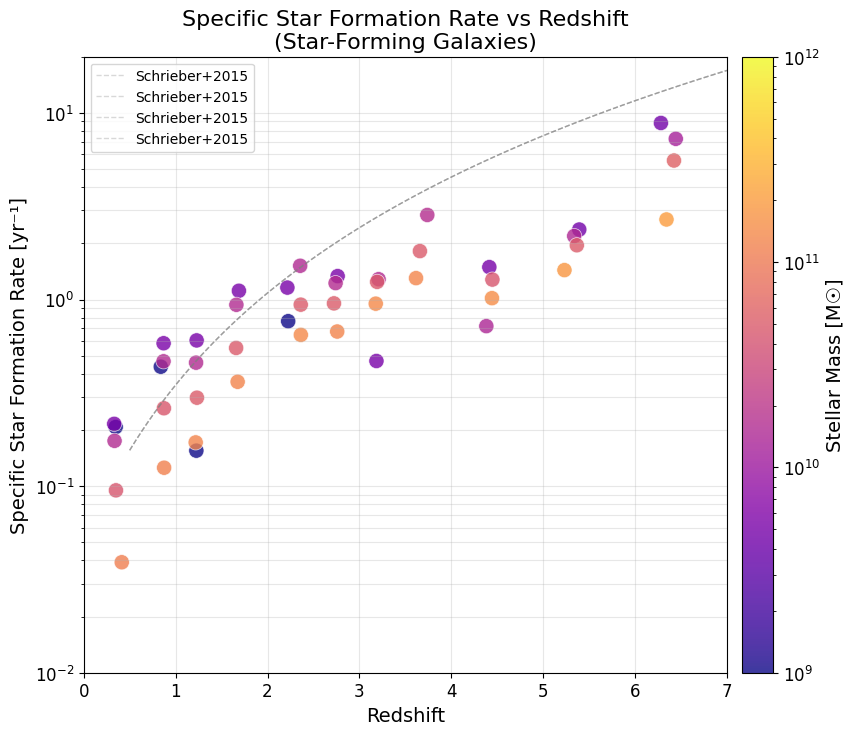

In [35]:
# Plot sSFR vs redshift  
print("\nCreating sSFR vs redshift plot...")
fig2, ax2 = plot_sfr_vs_redshift_by_mass(
    wrapper, 
    save_path=f'ssfr_vs_z_by_mass.png',
    figsize=(10, 8),
    plot_specific_sfr=True
)

plt.show()

Creating SFR vs redshift plot...
📊 Found 107 populations in summary
🌟 Found 55 star-forming populations
🔍 Found 47 detected star-forming populations
Redshift range: 0.33 - 6.44
SFR range: 0.1 - 538.1 M☉/yr
Median SFR: 19.9 M☉/yr
Stellar mass range: 7.20e+08 - 2.00e+11 M☉


/var/folders/y6/w9q_b49n5qzbxrbqfjs4qkpm0000gn/T/ipykernel_65456/155522046.py:140: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc='upper left')


💾 Figure saved to: sfr_vs_z_by_mass_20250712_130435.png


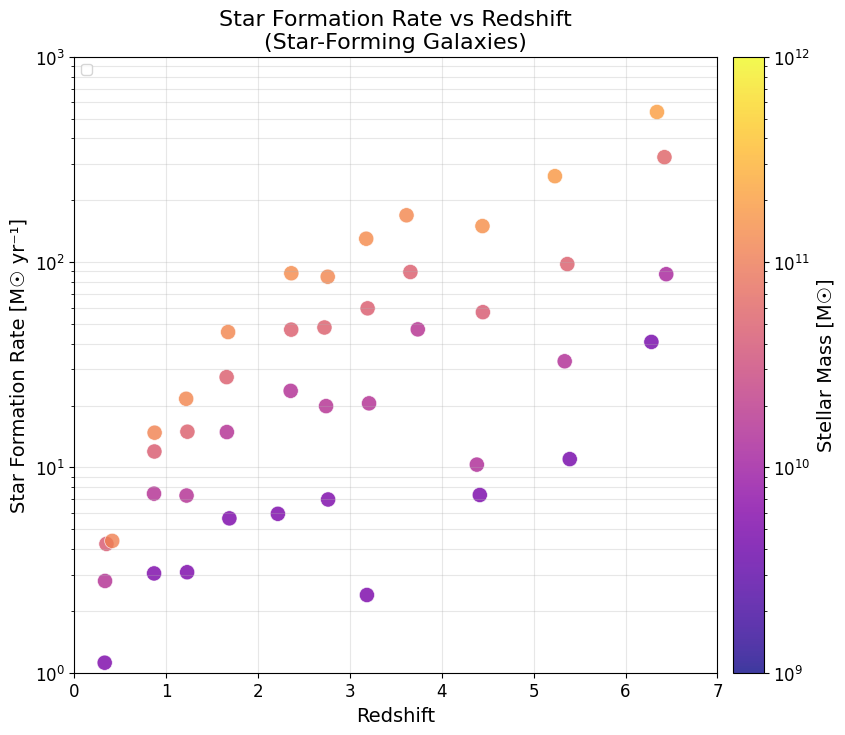

In [61]:

# Plot SFR vs redshift
print("Creating SFR vs redshift plot...")
fig1, ax1 = plot_sfr_vs_redshift_by_mass(
    wrapper, 
    save_path=f'sfr_vs_z_by_mass_{file_date}.png',
    figsize=(10, 8),
    plot_specific_sfr=False
)

plt.show()


In [36]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.colors import LogNorm
import seaborn as sns

def plot_sfrd_vs_redshift_by_mass_bins(wrapper, save_path=None, figsize=(12, 8), 
                                      include_literature=True, show_uncertainties=True,
                                      field_area_deg2=1.6):
    """
    Create star formation rate density (SFRD) vs redshift plot with separate lines for each stellar mass bin
    
    Parameters:
    -----------
    wrapper : SimstackWrapper
        Wrapper with processed results
    save_path : str or None
        Path to save figure
    figsize : tuple
        Figure size (width, height)
    include_literature : bool
        Whether to include literature comparisons
    show_uncertainties : bool
        Whether to show error bars on SFRD measurements
    field_area_deg2 : float
        Field area in square degrees (default 1.6 for COSMOS)
    """
    
    # Check if we have processed results
    if not wrapper.processed_results:
        print("❌ No processed results found. Running analysis...")
        wrapper.run_analysis_only()
    
    # Get population summary
    try:
        summary_df = wrapper.processed_results.get_population_summary()
        print(f"📊 Found {len(summary_df)} populations in summary")
    except Exception as e:
        print(f"❌ Could not get population summary: {e}")
        return None
    
    print(f"📏 Using field area: {field_area_deg2} deg²")
    
    # Filter for star-forming galaxies only
    sf_mask = summary_df['population_id'].str.contains('split_0', na=False)
    
    if not sf_mask.any():
        print("⚠️  No star-forming populations found (looking for 'split_0')")
        # Use all populations if no split found
        sf_mask = pd.Series([True] * len(summary_df))
        print("Using all populations instead...")
    
    sf_df = summary_df[sf_mask].copy()
    print(f"🌟 Found {len(sf_df)} star-forming populations")
    
    # Filter for detections
    detection_mask = (
        (sf_df['sfr_msun_yr'] > 0) & 
        (sf_df['total_ir_luminosity_lsun'] > 0) &
        (sf_df['n_sources'] > 0)
    )
    
    sf_detected = sf_df[detection_mask].copy()
    print(f"🔍 Found {len(sf_detected)} detected star-forming populations")
    
    if len(sf_detected) == 0:
        print("❌ No detected star-forming populations found")
        return None
    
    # Try to get cosmology calculator from wrapper
    cosmo_calc = None
    if hasattr(wrapper, 'cosmology_calc') and wrapper.cosmology_calc:
        cosmo_calc = wrapper.cosmology_calc
        print("✓ Using cosmology calculator from wrapper")
    elif hasattr(wrapper, 'processed_results') and hasattr(wrapper.processed_results, 'cosmology_calc'):
        cosmo_calc = wrapper.processed_results.cosmology_calc
        print("✓ Using cosmology calculator from processed results")
    else:
        print("⚠️  No cosmology calculator found, using simplified volume calculation")
    
    # Calculate SFRD for each population
    sfrd_data = []
    
    for _, pop in sf_detected.iterrows():
        # Extract redshift and mass bin information from population ID
        pop_id = pop['population_id']
        
        # Parse redshift bin
        try:
            parts = pop_id.split('__')
            redshift_part = [p for p in parts if 'redshift' in p][0]
            z_parts = redshift_part.split('_')
            z_min = float(z_parts[1])
            z_max = float(z_parts[2])
            z_center = (z_min + z_max) / 2
            dz = z_max - z_min
        except:
            z_center = pop['median_redshift']
            dz = 0.2
            z_min = z_center - dz/2
            z_max = z_center + dz/2
        
        # Parse stellar mass bin
        try:
            mass_part = [p for p in parts if 'stellar_mass' in p or 'mass' in p][0]
            m_parts = mass_part.split('_')
            m_min = float(m_parts[-2])
            m_max = float(m_parts[-1])
            m_center = (m_min + m_max) / 2
            mass_bin_label = f"{m_min:.1f}-{m_max:.1f}"
        except:
            # Fallback to median mass
            m_center = pop['median_log_mass']
            mass_bin_label = f"M~{m_center:.1f}"
        
        # Calculate comoving volume (same as before)
        if cosmo_calc is not None:
            try:
                vol_z1 = cosmo_calc.cosmology.comoving_volume(z_min)
                vol_z2 = cosmo_calc.cosmology.comoving_volume(z_max)
                vol0 = vol_z2 - vol_z1
                area_fraction = (field_area_deg2 / (180. / np.pi) ** 2.) / (4. * np.pi)
                vol_comoving_mpc3 = (area_fraction * vol0).value
            except Exception as e:
                print(f"⚠️  Cosmology calculation failed: {e}, using simplified method")
                cosmo_calc = None
        
        if cosmo_calc is None:
            # Simplified volume calculation
            area_sr = field_area_deg2 * (np.pi/180)**2
            H0 = 70
            c_km_s = 299792.458
            
            if z_center < 0.3:
                D_c = c_km_s * z_center / H0
                vol_comoving_mpc3 = area_sr * D_c**2 * (c_km_s / H0) * dz
            else:
                def E(z):
                    return np.sqrt(0.3 * (1 + z)**3 + 0.7)
                
                z_array = np.linspace(0, z_center, 100)
                dz_array = z_array[1] - z_array[0]
                integrand = 1 / E(z_array)
                D_c = (c_km_s / H0) * np.trapz(integrand, dx=dz_array)
                vol_comoving_mpc3 = area_sr * D_c**2 * (c_km_s / H0) * dz / E(z_center)
        
        # Calculate SFRD
        sfr_per_galaxy = pop['sfr_msun_yr']
        n_sources = pop['n_sources']
        total_sfr_in_volume = sfr_per_galaxy * n_sources
        
        completeness = 1.0
        sfrd = total_sfr_in_volume / vol_comoving_mpc3 / completeness
        
        # Error estimation
        sfr_error_per_galaxy = sfr_per_galaxy * 0.2
        cv = moster2011_cosmic_variance(z_center, dz)
        measurement_error = n_sources * sfr_error_per_galaxy
        cosmic_variance_error = total_sfr_in_volume * cv
        total_error = np.sqrt(measurement_error**2 + cosmic_variance_error**2)
        sfrd_error = total_error / vol_comoving_mpc3 / completeness
        
        sfrd_data.append({
            'z_center': z_center,
            'z_min': z_min,
            'z_max': z_max,
            'dz': dz,
            'm_center': m_center,
            'mass_bin_label': mass_bin_label,
            'sfrd': sfrd,
            'sfrd_error': sfrd_error,
            'n_sources': n_sources,
            'volume_mpc3': vol_comoving_mpc3,
            'total_sfr': total_sfr_in_volume,
            'population_id': pop_id
        })
    
    sfrd_df = pd.DataFrame(sfrd_data)
    
    # Group by redshift and mass bins
    mass_bins = sorted(sfrd_df['mass_bin_label'].unique())
    redshift_centers = sorted(sfrd_df['z_center'].unique())
    
    print(f"📊 Found {len(mass_bins)} mass bins: {mass_bins}")
    print(f"📊 Found {len(redshift_centers)} redshift bins: {redshift_centers}")
    
    # Create SFRD vs z for each mass bin
    mass_bin_data = {}
    total_sfrd_data = {'z_center': [], 'sfrd': [], 'sfrd_error': [], 'n_sources': []}
    
    for z_cent in redshift_centers:
        z_mask = np.abs(sfrd_df['z_center'] - z_cent) < 0.05
        z_data = sfrd_df[z_mask]
        
        # Calculate total SFRD at this redshift (sum over all mass bins)
        total_sfrd = z_data['sfrd'].sum()
        total_error = np.sqrt((z_data['sfrd_error']**2).sum())
        total_sources = z_data['n_sources'].sum()
        
        total_sfrd_data['z_center'].append(z_cent)
        total_sfrd_data['sfrd'].append(total_sfrd)
        total_sfrd_data['sfrd_error'].append(total_error)
        total_sfrd_data['n_sources'].append(total_sources)
        
        # Store data for each mass bin at this redshift
        for mass_bin in mass_bins:
            if mass_bin not in mass_bin_data:
                mass_bin_data[mass_bin] = {'z_center': [], 'sfrd': [], 'sfrd_error': [], 'n_sources': []}
            
            mass_data = z_data[z_data['mass_bin_label'] == mass_bin]
            
            if len(mass_data) > 0:
                # Sum SFRD if multiple populations in same mass+redshift bin
                mass_sfrd = mass_data['sfrd'].sum()
                mass_error = np.sqrt((mass_data['sfrd_error']**2).sum())
                mass_sources = mass_data['n_sources'].sum()
            else:
                # No data for this mass bin at this redshift
                mass_sfrd = np.nan
                mass_error = np.nan
                mass_sources = 0
            
            mass_bin_data[mass_bin]['z_center'].append(z_cent)
            mass_bin_data[mass_bin]['sfrd'].append(mass_sfrd)
            mass_bin_data[mass_bin]['sfrd_error'].append(mass_error)
            mass_bin_data[mass_bin]['n_sources'].append(mass_sources)
    
    # Create the plot
    fig, ax = plt.subplots(1, 1, figsize=figsize)
    
    # Define colors for mass bins
    colors = plt.cm.viridis(np.linspace(0, 1, len(mass_bins)))
    
    # Plot each mass bin
    for i, mass_bin in enumerate(mass_bins):
        data = mass_bin_data[mass_bin]
        z_arr = np.array(data['z_center'])
        sfrd_arr = np.array(data['sfrd'])
        error_arr = np.array(data['sfrd_error'])
        
        # Remove NaN values
        valid_mask = np.isfinite(sfrd_arr) & (sfrd_arr > 0)
        
        if np.sum(valid_mask) > 0:
            z_valid = z_arr[valid_mask]
            sfrd_valid = sfrd_arr[valid_mask]
            error_valid = error_arr[valid_mask]
            
            if show_uncertainties:
                ax.errorbar(z_valid, sfrd_valid, yerr=error_valid,
                           fmt='o-', color=colors[i], markersize=6, linewidth=2,
                           label=f'log(M*/M☉) = {mass_bin}', alpha=0.8, capsize=3)
            else:
                ax.plot(z_valid, sfrd_valid, 'o-', color=colors[i], 
                       markersize=6, linewidth=2, label=f'log(M*/M☉) = {mass_bin}', alpha=0.8)
    
    # Plot total SFRD (sum of all mass bins)
    total_z = np.array(total_sfrd_data['z_center'])
    total_sfrd = np.array(total_sfrd_data['sfrd'])
    total_error = np.array(total_sfrd_data['sfrd_error'])
    
    if show_uncertainties:
        ax.errorbar(total_z, total_sfrd, yerr=total_error,
                   fmt='s-', color='red', markersize=8, linewidth=3,
                   label='Total (all masses)', zorder=10, capsize=5)
    else:
        ax.plot(total_z, total_sfrd, 's-', color='red', 
               markersize=8, linewidth=3, label='Total (all masses)', zorder=10)
    
    # Add literature comparisons if requested
    if include_literature:
        # Béthermin+2017
        bethermin_z = np.array([0.35, 0.55, 0.75, 0.95, 1.15, 1.4, 1.7, 2.0, 2.3, 2.7, 3.2, 3.8])
        bethermin_sfrd = np.array([0.008, 0.015, 0.025, 0.04, 0.06, 0.08, 0.09, 0.09, 0.08, 0.06, 0.04, 0.02])
        bethermin_err = bethermin_sfrd * 0.3
        
        ax.errorbar(bethermin_z, bethermin_sfrd, yerr=bethermin_err,
                   fmt='v', color='blue', markersize=5, alpha=0.6,
                   label='Béthermin+2017 (IR)', zorder=3)
        
        # Zavala+2022
        zavala_z = np.array([4.5, 5.5])
        zavala_sfrd = np.array([0.01, 0.005])
        zavala_err = zavala_sfrd * 0.5
        
        ax.errorbar(zavala_z, zavala_sfrd, yerr=zavala_err,
                   fmt='^', color='green', markersize=6, alpha=0.6,
                   label='Zavala+2022 ([CII])', zorder=3)
        
        # Madau & Dickinson 2014
        z_md = np.linspace(0, 6, 100)
        sfrd_md = 0.015 * (1 + z_md)**2.7 / (1 + ((1 + z_md)/2.9)**5.6)
        ax.plot(z_md, sfrd_md, '--', color='black', linewidth=2, alpha=0.5,
                label='Madau & Dickinson 2014', zorder=1)
        
        # Driver+2018
        ax.scatter([0.05], [0.0076], marker='*', s=150, color='orange', 
                  edgecolors='black', linewidth=1,
                  label='Driver+2018 (z~0)', zorder=8)
    
    # Formatting
    ax.set_xlabel('Redshift', fontsize=14)
    ax.set_ylabel('Star Formation Rate Density [M☉ yr⁻¹ Mpc⁻³]', fontsize=14)
    ax.set_title('Cosmic Star Formation Rate Density by Stellar Mass', fontsize=16)
    
    # Set scales and limits
    ax.set_yscale('log')
    ax.set_xlim(0, 6)
    ax.set_ylim(1e-5, 1)
    
    # Grid and formatting
    ax.grid(True, alpha=0.3, which='both')
    ax.tick_params(axis='both', which='major', labelsize=12)
    
    # Legend (split into two columns if many mass bins)
    if len(mass_bins) > 4:
        ax.legend(fontsize=10, loc='upper right', ncol=2)
    else:
        ax.legend(fontsize=11, loc='upper right')
    
    # Add text with survey info
    volume_method = "Exact cosmology" if cosmo_calc else "Simplified approximation"
    ax.text(0.05, 0.05, f'Field area: {field_area_deg2:.1f} deg²\nMass bins: {len(mass_bins)}\nVolume: {volume_method}', 
            transform=ax.transAxes, fontsize=10, 
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.8),
            verticalalignment='bottom')
    
    plt.tight_layout()
    
    # Print statistics
    print(f"\n📈 SFRD by Mass Bin:")
    print(f"Field area used: {field_area_deg2:.1f} deg²")
    print(f"Volume calculation method: {'Exact cosmology' if cosmo_calc else 'Simplified approximation'}")
    
    for mass_bin in mass_bins:
        data = mass_bin_data[mass_bin]
        valid_mask = np.isfinite(data['sfrd']) & (np.array(data['sfrd']) > 0)
        if np.sum(valid_mask) > 0:
            print(f"\nMass bin log(M*/M☉) = {mass_bin}:")
            for j, (z, sfrd, err, n) in enumerate(zip(data['z_center'], data['sfrd'], data['sfrd_error'], data['n_sources'])):
                if np.isfinite(sfrd) and sfrd > 0:
                    print(f"  z={z:.1f}: SFRD={sfrd:.3e}±{err:.3e} M☉/yr/Mpc³ ({n} sources)")
    
    print(f"\nTotal SFRD (all mass bins):")
    for z, sfrd, err, n in zip(total_sfrd_data['z_center'], total_sfrd_data['sfrd'], total_sfrd_data['sfrd_error'], total_sfrd_data['n_sources']):
        print(f"  z={z:.1f}: SFRD={sfrd:.3e}±{err:.3e} M☉/yr/Mpc³ ({n} sources)")
    
    # Save if requested
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight', 
                   facecolor='white', edgecolor='none')
        print(f"💾 Figure saved to: {save_path}")
    
    return fig, ax, mass_bin_data, total_sfrd_data

def moster2011_cosmic_variance(z, dz=0.2, field='cosmos'):
    """
    Cosmic variance following Moster+2011 (same as in simstackcosmologyestimators.py)
    """
    cv_params = {'cosmos': [0.069, -.234, 0.834], 'udf': [0.251, 0.364, 0.358],
                'goods': [0.261, 0.854, 0.684], 'gems': [0.161, 0.520, 0.729],
                'egs': [0.128, 0.383, 0.673]}

    field_params = cv_params[field]
    sigma_cv_ref = field_params[0] / (z ** field_params[2] + field_params[1])

    if dz == 0.2:
        sigma_cv = sigma_cv_ref
    else:
        sigma_cv = sigma_cv_ref * (dz / 0.2) ** (-0.5)

    return sigma_cv



Creating SFRD vs redshift plot by mass bins...
📊 Found 107 populations in summary
📏 Using field area: 0.513 deg²
🌟 Found 55 star-forming populations
🔍 Found 47 detected star-forming populations
✓ Using cosmology calculator from processed results
⚠️  Cosmology calculation failed: 'CosmologyCalculator' object has no attribute 'cosmology', using simplified method
📊 Found 5 mass bins: ['10.0-10.5', '10.5-11.0', '11.0-12.0', '8.5-9.5', '9.5-10.0']
📊 Found 11 redshift bins: [np.float64(0.255), np.float64(0.75), np.float64(1.25), np.float64(1.75), np.float64(2.25), np.float64(2.75), np.float64(3.25), np.float64(3.75), np.float64(4.5), np.float64(5.5), np.float64(7.0)]

📈 SFRD by Mass Bin:
Field area used: 0.5 deg²
Volume calculation method: Simplified approximation

Mass bin log(M*/M☉) = 10.0-10.5:
  z=0.3: SFRD=3.084e-03±1.698e-03 M☉/yr/Mpc³ (431 sources)
  z=0.8: SFRD=1.078e-02±2.318e-03 M☉/yr/Mpc³ (2237 sources)
  z=1.2: SFRD=5.349e-03±1.096e-03 M☉/yr/Mpc³ (1812 sources)
  z=1.8: SFRD=8.98

/var/folders/y6/w9q_b49n5qzbxrbqfjs4qkpm0000gn/T/ipykernel_68619/298817428.py:144: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  D_c = (c_km_s / H0) * np.trapz(integrand, dx=dz_array)


💾 Figure saved to: sfrd_vs_z_by_mass_bins_20250712_130435.png


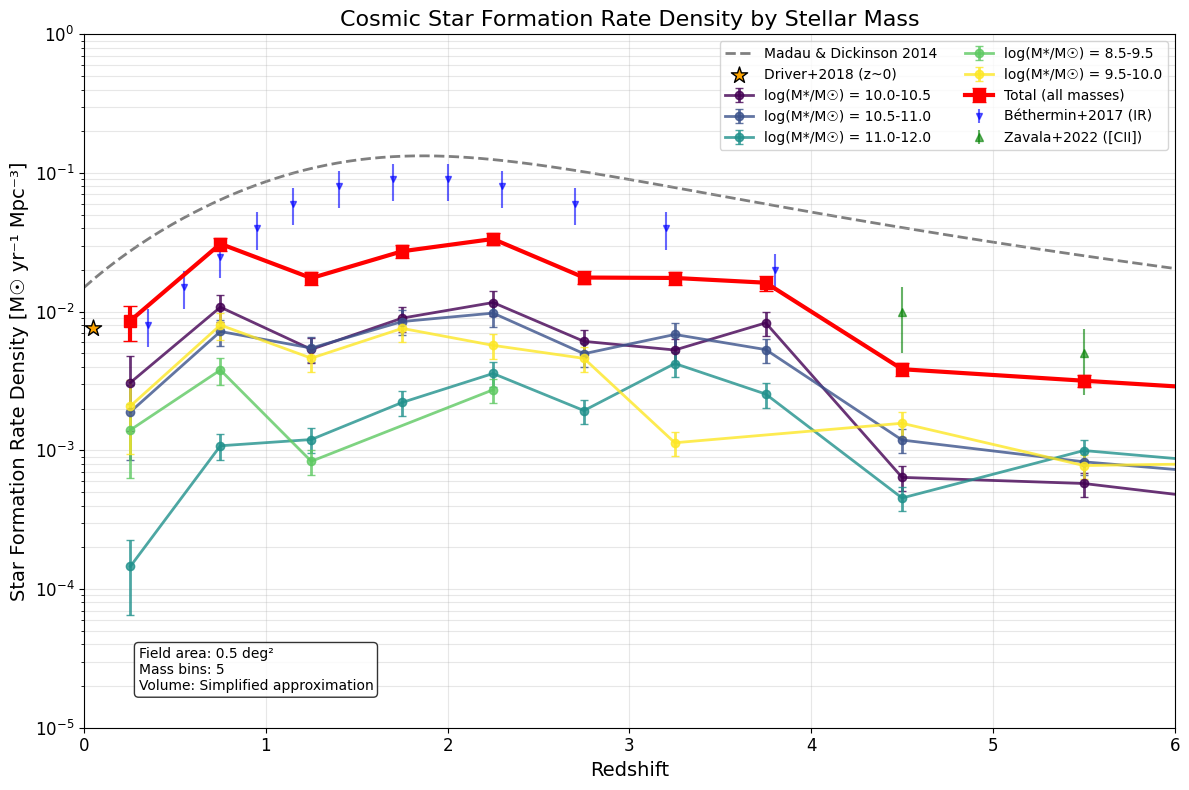

In [37]:
# Usage example:
print("Creating SFRD vs redshift plot by mass bins...")
fig, ax, mass_data, total_data = plot_sfrd_vs_redshift_by_mass_bins(
    wrapper, 
    save_path=f'sfrd_vs_z_by_mass_bins_{file_date}.png',
    figsize=(12, 8),
    include_literature=True,
    show_uncertainties=True,
    field_area_deg2=0.54 * 0.95
)

plt.show()

In [16]:
def create_lir_luv_beta_plot(wrapper, 
                              show_errors=True,
                              figsize=(10, 8),
                              color_by='redshift',
                              average_luv=False,
                              save_path=None, 
                              xlim=None,
                              ylim=None,
                            ):
    """
    Create L_IR/L_UV vs β_UV plot from SimstackWrapper results
    
    Parameters:
    -----------
    wrapper : SimstackWrapper
        Wrapper object with stacking_results and processed_results
    show_errors : bool
        Whether to show error bars
    figsize : tuple
        Figure size (width, height)
    color_by : str
        What to color points by: 'redshift' (default) or 'l_uv'
    average_luv : bool
        If True, average over L_UV bins (collapse L_UV dimension)
    save_path : str or Path or None
        Path to save the figure (PDF, PNG, etc. based on extension)
    """
    
    # Get results from wrapper
    if not hasattr(wrapper, 'stacking_results') or wrapper.stacking_results is None:
        print("❌ No stacking results found in wrapper")
        return None
        
    if not hasattr(wrapper, 'processed_results') or wrapper.processed_results is None:
        print("❌ No processed results found in wrapper")
        return None
    
    # Get summary dataframe
    try:
        if hasattr(wrapper.processed_results, 'get_population_summary'):
            summary_df = wrapper.processed_results.get_population_summary()
        else:
            summary_df = wrapper.population_manager.get_population_summary()
        
        print(f"📋 Available columns: {list(summary_df.columns)}")
        
    except Exception as e:
        print(f"❌ Could not get population summary: {e}")
        return None
    
    # Determine the correct population ID column name
    pop_id_col = None
    possible_id_cols = ['id_label', 'population_id', 'pop_id', 'label']
    
    for col in possible_id_cols:
        if col in summary_df.columns:
            pop_id_col = col
            break
    
    if pop_id_col is None:
        print(f"❌ Could not find population ID column. Available columns: {list(summary_df.columns)}")
        return None
    
    # Filter for detected populations only
    df = summary_df.copy()
    
    # Check if we have L_IR measurements
    lir_cols = [col for col in df.columns if 'ir_luminosity' in col.lower()]
    if not lir_cols:
        print("❌ No L_IR measurements found")
        return None
    
    lir_col = lir_cols[0]
    df = df[df[lir_col] > 0]
    print(f"🔍 Using {lir_col} for L_IR")
    
    if len(df) == 0:
        print("❌ No detected populations found")
        return None
    
    print(f"✅ Found {len(df)} detected populations")
    
    # Parse population information to extract β_UV and L_UV
    def parse_population_id(pop_id):
        """Extract binning information from population ID"""
        try:
            parts = pop_id.split('__')
            bin_info = {}
            
            for part in parts:
                if '_' in part:
                    elements = part.split('_')
                    if len(elements) >= 3:
                        try:
                            min_val = float(elements[-2])
                            max_val = float(elements[-1])
                            bin_name = '_'.join(elements[:-2])
                            bin_info[bin_name] = (min_val, max_val)
                        except ValueError:
                            continue
            
            return bin_info
        except Exception as e:
            print(f"⚠️  Could not parse population ID: {pop_id}")
            return {}
    
    # Parse all population IDs
    parsed_info = df[pop_id_col].apply(parse_population_id)
    
    # Extract β_UV, L_UV, and redshift values
    beta_uv_values = []
    l_uv_values = []
    redshift_values = []
    l_ir_luv_ratios = []
    
    # Color scheme for population types (backup if not using colorbar)
    has_split = any('split' in str(pop_id) for pop_id in df[pop_id_col])
    
    for idx, (_, pop) in enumerate(df.iterrows()):
        pop_id = pop[pop_id_col]
        bin_info = parsed_info.iloc[idx]
        
        # Extract β_UV and redshift from binning
        beta_uv = None
        l_uv = None
        redshift = None
        
        for bin_name, (min_val, max_val) in bin_info.items():
            if 'beta' in bin_name.lower():
                beta_uv = (min_val + max_val) / 2  # Use bin center
            elif 'l_uv' in bin_name.lower() or 'luv' in bin_name.lower():
                l_uv = (min_val + max_val) / 2  # Use bin center
            elif 'redshift' in bin_name.lower() or bin_name.lower() == 'z':
                redshift = (min_val + max_val) / 2  # Use bin center
        
        # Also try to get redshift from median_redshift column
        if redshift is None and 'median_redshift' in pop:
            redshift = pop['median_redshift']
        
        # Get L_IR
        l_ir = pop[lir_col]
        
        # Only include if we have all required values
        if beta_uv is not None and l_uv is not None and l_ir > 0:
            beta_uv_values.append(beta_uv)
            l_uv_values.append(l_uv)
            redshift_values.append(redshift if redshift is not None else np.nan)
            
            # Calculate L_IR/L_UV ratio
            # L_UV is in log space, so convert: L_UV = 10^l_uv
            l_uv_linear = 10**l_uv
            l_ir_luv_ratio = np.log10(l_ir / l_uv_linear)
            l_ir_luv_ratio = (l_ir / l_uv_linear)
            l_ir_luv_ratios.append(l_ir_luv_ratio)
    
    if len(beta_uv_values) == 0:
        print("❌ No populations found with both β_UV and L_UV binning")
        return None
    
    print(f"📊 Found {len(beta_uv_values)} populations with β_UV and L_UV data")
    
    # Convert to arrays
    beta_uv_values = np.array(beta_uv_values)
    l_uv_values = np.array(l_uv_values)
    redshift_values = np.array(redshift_values)
    l_ir_luv_ratios = np.array(l_ir_luv_ratios)
    
    # Optional: Average over L_UV bins
    if average_luv:
        print("📊 Averaging over L_UV bins...")
        
        # Group by unique β_UV and redshift bins, average over L_UV
        unique_combinations = {}
        
        for i in range(len(beta_uv_values)):
            # Create key from β_UV and redshift (rounded for grouping)
            beta_key = round(beta_uv_values[i], 2)
            redshift_key = round(redshift_values[i], 2) if np.isfinite(redshift_values[i]) else 'nan'
            key = (beta_key, redshift_key)
            
            if key not in unique_combinations:
                unique_combinations[key] = {
                    'beta_uv': [],
                    'l_uv': [],
                    'redshift': [],
                    'l_ir_luv': []
                }
            
            unique_combinations[key]['beta_uv'].append(beta_uv_values[i])
            unique_combinations[key]['l_uv'].append(l_uv_values[i])
            unique_combinations[key]['redshift'].append(redshift_values[i])
            unique_combinations[key]['l_ir_luv'].append(l_ir_luv_ratios[i])
        
        # Average the grouped values
        beta_uv_avg = []
        l_uv_avg = []
        redshift_avg = []
        l_ir_luv_avg = []
        l_ir_luv_std = []
        
        for key, values in unique_combinations.items():
            beta_uv_avg.append(np.mean(values['beta_uv']))
            l_uv_avg.append(np.mean(values['l_uv']))
            redshift_avg.append(np.mean(values['redshift']))
            l_ir_luv_avg.append(np.mean(values['l_ir_luv']))
            l_ir_luv_std.append(np.std(values['l_ir_luv']) if len(values['l_ir_luv']) > 1 else 0)
        
        # Replace arrays with averaged values
        beta_uv_values = np.array(beta_uv_avg)
        l_uv_values = np.array(l_uv_avg)
        redshift_values = np.array(redshift_avg)
        l_ir_luv_ratios = np.array(l_ir_luv_avg)
        l_ir_luv_errors = np.array(l_ir_luv_std)
        
        print(f"📊 Reduced to {len(beta_uv_values)} averaged points")
    
    # Create the plot
    fig, ax = plt.subplots(1, 1, figsize=figsize)
    
    # Determine what to color by
    if color_by == 'l_uv':
        color_values = l_uv_values
        color_label = 'log L_UV/L_☉'
        cmap = 'viridis'
    else:  # default to redshift
        color_values = redshift_values
        color_label = 'Redshift'
        cmap = 'plasma'
    
    # Check if we have valid color values
    valid_color_mask = np.isfinite(color_values)
    if not np.any(valid_color_mask):
        print(f"⚠️  No valid {color_by} values found, using default colors")
        # Fall back to discrete colors
        scatter = ax.scatter(beta_uv_values, l_ir_luv_ratios, 
                            c='blue', s=100, alpha=0.8, 
                            edgecolors='black', linewidth=0.5)
    else:
        # Use colormap
        import matplotlib.cm as cm
        from matplotlib.colors import Normalize, BoundaryNorm, ListedColormap
        
        # Only use valid points for colormap
        valid_color_values = color_values[valid_color_mask]
        
        # DISCRETE COLORBAR OPTION
        use_discrete_colorbar = True  # Set to False for continuous
        
        if use_discrete_colorbar:
            # Create discrete bins
            if color_by == 'redshift':
                # Define redshift bins
                z_bins = np.array([0, 0.5, 1.0, 1.5, 2.0, 2.5, 3.0, 4.0, 6.0])
                z_bins = z_bins[z_bins <= np.max(valid_color_values) * 1.1]  # Only use relevant bins
                
                # Create discrete colormap
                n_colors = len(z_bins) - 1
                colors = cm.get_cmap('plasma', n_colors)
                discrete_cmap = ListedColormap([colors(i) for i in range(n_colors)])
                
                # Create boundary normalization
                norm = BoundaryNorm(z_bins, discrete_cmap.N)
                
                # Labels for colorbar
                bin_labels = [f'{z_bins[i]:.1f}-{z_bins[i+1]:.1f}' for i in range(len(z_bins)-1)]
                
            elif color_by == 'l_uv':
                # Define L_UV bins
                luv_min, luv_max = np.min(valid_color_values), np.max(valid_color_values)
                luv_bins = np.linspace(luv_min, luv_max, 6)  # 5 discrete bins
                
                # Create discrete colormap
                n_colors = len(luv_bins) - 1
                colors = cm.get_cmap('viridis', n_colors)
                discrete_cmap = ListedColormap([colors(i) for i in range(n_colors)])
                
                # Create boundary normalization
                norm = BoundaryNorm(luv_bins, discrete_cmap.N)
                
                # Labels for colorbar
                bin_labels = [f'{luv_bins[i]:.1f}-{luv_bins[i+1]:.1f}' for i in range(len(luv_bins)-1)]
            
            else:
                # Generic discrete binning
                val_min, val_max = np.min(valid_color_values), np.max(valid_color_values)
                bins = np.linspace(val_min, val_max, 6)  # 5 discrete bins
                
                n_colors = len(bins) - 1
                colors = cm.get_cmap(cmap, n_colors)
                discrete_cmap = ListedColormap([colors(i) for i in range(n_colors)])
                norm = BoundaryNorm(bins, discrete_cmap.N)
                bin_labels = [f'{bins[i]:.1f}-{bins[i+1]:.1f}' for i in range(len(bins)-1)]
            
            print(f"🎨 Using discrete colorbar with {len(bin_labels)} bins")
            
        else:
            # Continuous colorbar (original)
            norm = Normalize(vmin=np.min(valid_color_values), vmax=np.max(valid_color_values))
            discrete_cmap = cmap
        
        # Plot points with colormap
        if average_luv and show_errors and 'l_ir_luv_errors' in locals():
            # Plot with error bars if averaged
            scatter = ax.errorbar(beta_uv_values, l_ir_luv_ratios, 
                                yerr=l_ir_luv_errors,
                                fmt='o', c=color_values, cmap=discrete_cmap, 
                                markersize=8, capsize=3, linewidth=1.5,
                                alpha=0.8, markeredgecolor='black', markeredgewidth=0.5)
            # Note: errorbar doesn't support direct colormap, so we'll handle this differently
            scatter = ax.scatter(beta_uv_values, l_ir_luv_ratios, 
                                c=color_values, cmap=discrete_cmap, s=100, alpha=0.8, 
                                edgecolors='black', linewidth=0.5, norm=norm, zorder=5)
            # Add error bars separately
            ax.errorbar(beta_uv_values, l_ir_luv_ratios, 
                       yerr=l_ir_luv_errors, fmt='none', 
                       color='gray', alpha=0.6, capsize=2, zorder=1)
        else:
            # Regular scatter plot
            scatter = ax.scatter(beta_uv_values, l_ir_luv_ratios, 
                                c=color_values, cmap=discrete_cmap, s=100, alpha=0.8, 
                                edgecolors='black', linewidth=0.5, norm=norm)
        
        # Add colorbar
        cbar = plt.colorbar(scatter, ax=ax, fraction=0.046, pad=0.04)
        cbar.set_label(color_label, fontsize=14, fontweight='bold')
        
        # Customize colorbar for discrete colors
        if use_discrete_colorbar:
            # Set tick positions and labels
            tick_positions = norm.boundaries[:-1] + np.diff(norm.boundaries) / 2
            cbar.set_ticks(tick_positions)
            cbar.set_ticklabels(bin_labels, fontsize=10)
            
            # Optional: Add lines between discrete colors
            for boundary in norm.boundaries[1:-1]:
                cbar.ax.axhline(boundary, color='white', linewidth=0.8)
        else:
            cbar.ax.tick_params(labelsize=12)
    
    # Set labels and scale
    ax.set_xlabel('β_UV', fontsize=16, fontweight='bold')
    ax.set_ylabel('log(L_IR/L_UV)', fontsize=16, fontweight='bold')
    #ax.set_ylim(np.log10([5e-3,4e3]))
    #if ylim is None:
    #    ax.set_ylim(10**np.array([5e-3,4e3]))
    #else:
    #    ax.set_ylim(10**np.array(ylim))
    ax.tick_params(axis='both', which='major', labelsize=14)
    ax.grid(True, alpha=0.3)
    
    # Add title
    title = f"L_IR/L_UV vs β_UV ({len(beta_uv_values)} {'averaged ' if average_luv else ''}populations)"
    ax.set_title(title, fontsize=18, fontweight='bold', pad=20)
    
    # Add legend for population types if we have them and not using colorbar
    if has_split and (not np.any(valid_color_mask)):
        from matplotlib.patches import Patch
        legend_elements = [Patch(facecolor='red', alpha=0.6, label='Star-forming'),
                          Patch(facecolor='teal', alpha=0.6, label='Quiescent')]
        ax.legend(handles=legend_elements, loc='upper left', fontsize=12, frameon=True,
                 title='Population Type', title_fontsize=12)
    
    # Set reasonable limits
    if xlim is None:
        ax.set_xlim(np.min(beta_uv_values) - 0.2, np.max(beta_uv_values) + 0.2)
    else:
        ax.set_xlim(xlim)
    
    # Add some reference lines if useful
    if np.min(beta_uv_values) < -1 and np.max(beta_uv_values) > 0:
        ax.axvline(x=-2.0, color='gray', linestyle='--', alpha=0.5, label='β_UV = -2.0 (typical)')

    # Literature relations - UPDATED with SMC-like curve
    beta_model = np.linspace(-2.5, 1.5, 100)
    
    # Meurer et al. 1999 (MW-like, starburst galaxies)
    irx_meurer = np.log10(10**(0.4 * (4.43 + 1.99 * beta_model)) - 1)
    irx_meurer = (10**(0.4 * (4.43 + 1.99 * beta_model)) - 1)
    ax.plot(beta_model, irx_meurer, 'k--', linewidth=2.5, alpha=0.8, 
           label='Meurer+99 (MW-like)')
    
    # Overzier et al. 2011 (refined calibration)
    #irx_overzier = np.log10(10**(0.4 * (4.54 + 2.07 * beta_model)) - 1)
    irx_overzier = (10**(0.4 * (4.54 + 2.07 * beta_model)) - 1)
    ax.plot(beta_model, irx_overzier, 'g--', linewidth=2, alpha=0.7, 
           label='Overzier+11')
    
    # SMC-like relation (Prevot et al. 1984, steeper FUV extinction)
    # SMC extinction curve has RV ≈ 2.93 (vs MW RV ≈ 3.1) and steeper FUV rise
    # This leads to a different IRX-β relation with shallower slope
    # Based on modeling studies (e.g., Reddy et al. 2018, Narayanan et al. 2018)
    # SMC-like curves produce flatter IRX-β relations
    #irx_smc = np.log10(10**(0.4 * (3.8 + 1.6 * beta_model)) - 1)
    irx_smc = (10**(0.4 * (3.8 + 1.6 * beta_model)) - 1)
    ax.plot(beta_model, irx_smc, '-.', color='brown', linewidth=2.5, alpha=0.8,
           label='SMC-like (Prevot+84)')
    
    # Alternative SMC parameterization from literature
    # Some studies suggest even flatter relations for low-metallicity systems
    #irx_smc_alt = np.log10(10**(0.4 * (3.2 + 1.4 * beta_model)) - 1)
    #ax.plot(beta_model, irx_smc_alt, ':', color='brown', linewidth=2, alpha=0.6,
    #       label='SMC-like (alternative)')
    
    # Add legend for curves
    ax.legend(loc='upper left', fontsize=11, frameon=True, framealpha=0.9)
        
    #ax.set_xlim(([-3.5,0.5]))
    #ax.set_ylim(([-1,3]))
    #ax.set_xscale('log')
    #ax.set_xlim([-3,1.1])
    #ax.set_ylim(10**np.array([-1.2,2.5]))
    ax.set_yscale('log')
    plt.tight_layout()
    
    # Save figure if path provided
    if save_path is not None:
        try:
            from pathlib import Path
            save_path = Path(save_path)
            save_path.parent.mkdir(parents=True, exist_ok=True)
            
            dpi = 300 if save_path.suffix.lower() in ['.png', '.jpg', '.jpeg'] else 150
            plt.savefig(save_path, dpi=dpi, bbox_inches='tight', 
                       facecolor='white', edgecolor='none')
            print(f"💾 Figure saved to: {save_path}")
            
        except Exception as e:
            print(f"⚠️  Could not save figure: {e}")
    
    # Print summary
    print(f"\n📈 Plot Summary:")
    print(f"   β_UV range: {np.min(beta_uv_values):.2f} to {np.max(beta_uv_values):.2f}")
    if not average_luv:
        print(f"   L_UV range: {np.min(l_uv_values):.2f} to {np.max(l_uv_values):.2f}")
    if np.any(valid_color_mask):
        print(f"   {color_label} range: {np.min(valid_color_values):.2f} to {np.max(valid_color_values):.2f}")
    print(f"   L_IR/L_UV range: {np.min(l_ir_luv_ratios):.2e} to {np.max(l_ir_luv_ratios):.2e}")
    print(f"   Median L_IR/L_UV: {np.median(l_ir_luv_ratios):.2e}")
    print(f"   Colored by: {color_by}")
    print(f"   L_UV averaging: {'ON' if average_luv else 'OFF'}")
    
    return fig

📋 Available columns: ['population_id', 'n_sources', 'median_redshift', 'median_log_mass', 'n_bands', 'greybody_fit_success', 'dust_temperature_rest_frame_K', 'dust_temperature_observed_frame_K', 'dust_temperature_error_K', 'emissivity_index', 'chi2_reduced', 'total_ir_luminosity_lsun', 'total_ir_luminosity_error_lsun', 'dust_mass_msun', 'sfr_msun_yr', 'specific_sfr_yr']
🔍 Using total_ir_luminosity_lsun for L_IR
✅ Found 73 detected populations
📊 Found 73 populations with β_UV and L_UV data
🎨 Using discrete colorbar with 8 bins

📈 Plot Summary:
   β_UV range: -2.00 to 1.00
   L_UV range: 9.50 to 11.50
   Redshift range: 0.26 to 7.50
   L_IR/L_UV range: 5.44e-02 to 1.54e+02
   Median L_IR/L_UV: 4.82e+00
   Colored by: redshift
   L_UV averaging: OFF


/var/folders/y6/w9q_b49n5qzbxrbqfjs4qkpm0000gn/T/ipykernel_46415/1604949118.py:258: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = cm.get_cmap('plasma', n_colors)
/var/folders/y6/w9q_b49n5qzbxrbqfjs4qkpm0000gn/T/ipykernel_46415/1604949118.py:377: RuntimeWarning: invalid value encountered in log10
  irx_meurer = np.log10(10**(0.4 * (4.43 + 1.99 * beta_model)) - 1)


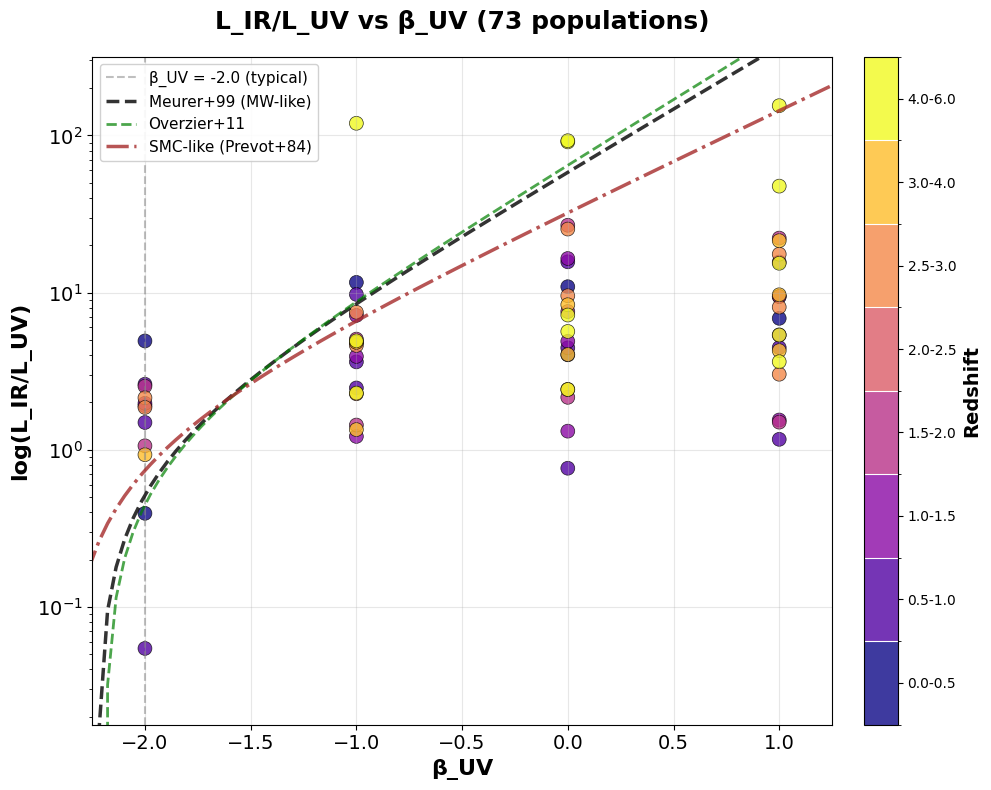

In [12]:
fig = create_lir_luv_beta_plot(
    wrapper, 
    color_by='redshift', 
    xlim=[-2.25,1.25],
    ylim=[-1.75,2.5],
)

📋 Available columns: ['population_id', 'n_sources', 'median_redshift', 'median_log_mass', 'n_bands', 'greybody_fit_success', 'dust_temperature_rest_frame_K', 'dust_temperature_observed_frame_K', 'dust_temperature_error_K', 'emissivity_index', 'chi2_reduced', 'total_ir_luminosity_lsun', 'total_ir_luminosity_error_lsun', 'dust_mass_msun', 'sfr_msun_yr', 'specific_sfr_yr']
🔍 Using total_ir_luminosity_lsun for L_IR
✅ Found 78 detected populations
📊 Found 78 populations with β_UV and L_UV data
🎨 Using discrete colorbar with 8 bins

📈 Plot Summary:
   β_UV range: -2.00 to 1.00
   L_UV range: 9.50 to 11.50
   Redshift range: 0.26 to 7.50
   L_IR/L_UV range: -1.11e+01 to 3.97e+00
   Median L_IR/L_UV: 1.48e-01
   Colored by: redshift
   L_UV averaging: OFF


/var/folders/y6/w9q_b49n5qzbxrbqfjs4qkpm0000gn/T/ipykernel_37487/1721449658.py:254: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = cm.get_cmap('plasma', n_colors)
/var/folders/y6/w9q_b49n5qzbxrbqfjs4qkpm0000gn/T/ipykernel_37487/1721449658.py:366: RuntimeWarning: invalid value encountered in log10
  irx_meurer = np.log10(10**(0.4 * (4.43 + 1.99 * beta_model)) - 1)
/var/folders/y6/w9q_b49n5qzbxrbqfjs4qkpm0000gn/T/ipykernel_37487/1721449658.py:371: RuntimeWarning: invalid value encountered in log10
  irx_overzier = np.log10(10**(0.4 * (4.54 + 2.07 * beta_model)) - 1)
/var/folders/y6/w9q_b49n5qzbxrbqfjs4qkpm0000gn/T/ipykernel_37487/1721449658.py:380: RuntimeWarning: invalid value encountered in log10
  irx_smc = np.log10(10**(0.4 * (3.8 + 1.6 * beta_model)) - 1)
/var/folders/y6/w9q_b49n5qzbxrbqfjs4qkpm0000g

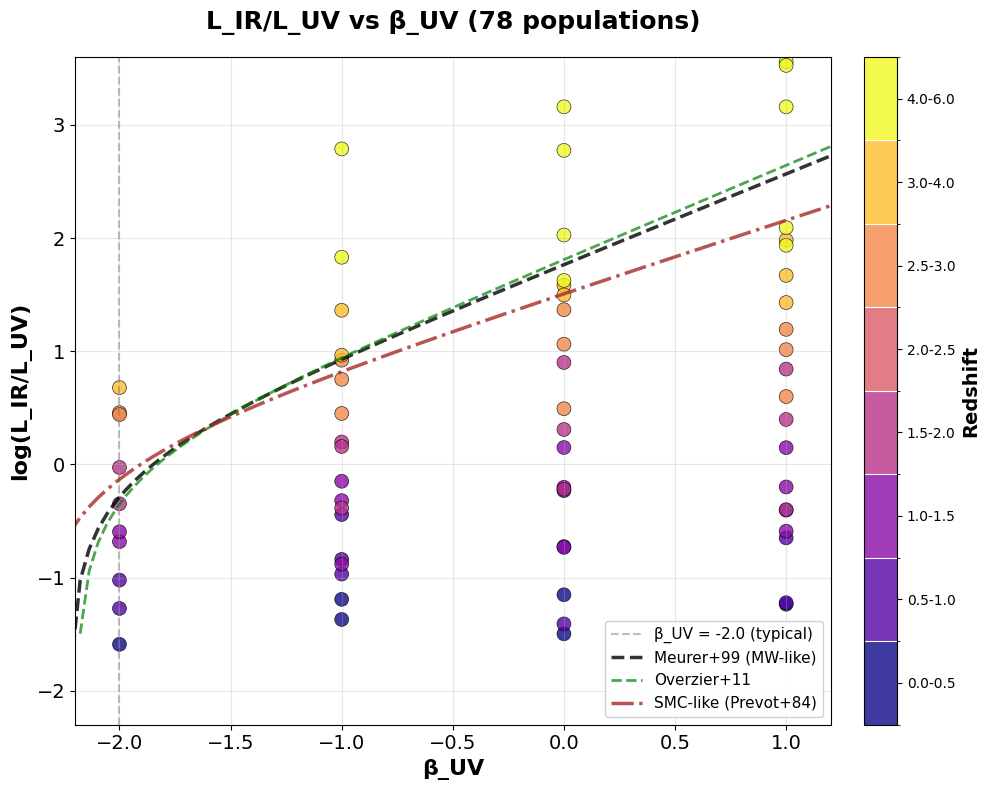

In [17]:
lir_luv_beta = create_lir_luv_beta_plot(wrapper)

📋 Available columns: ['population_id', 'n_sources', 'median_redshift', 'median_log_mass', 'n_bands', 'greybody_fit_success', 'dust_temperature_rest_frame_K', 'dust_temperature_observed_frame_K', 'dust_temperature_error_K', 'emissivity_index', 'chi2_reduced', 'total_ir_luminosity_lsun', 'total_ir_luminosity_error_lsun', 'dust_mass_msun', 'sfr_msun_yr', 'specific_sfr_yr']
🔍 Using total_ir_luminosity_lsun for L_IR
✅ Found 73 detected populations
📊 Found 73 populations with β_UV and L_UV data
🎨 Using discrete colorbar with 8 bins

📈 Plot Summary:
   β_UV range: -2.00 to 1.00
   L_UV range: 9.50 to 11.50
   Redshift range: 0.26 to 7.50
   L_IR/L_UV range: 5.44e-02 to 1.54e+02
   Median L_IR/L_UV: 4.82e+00
   Colored by: redshift
   L_UV averaging: OFF


/var/folders/y6/w9q_b49n5qzbxrbqfjs4qkpm0000gn/T/ipykernel_46415/3185384589.py:258: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = cm.get_cmap('plasma', n_colors)
/var/folders/y6/w9q_b49n5qzbxrbqfjs4qkpm0000gn/T/ipykernel_46415/3185384589.py:377: RuntimeWarning: invalid value encountered in log10
  irx_meurer = np.log10(10**(0.4 * (4.43 + 1.99 * beta_model)) - 1)


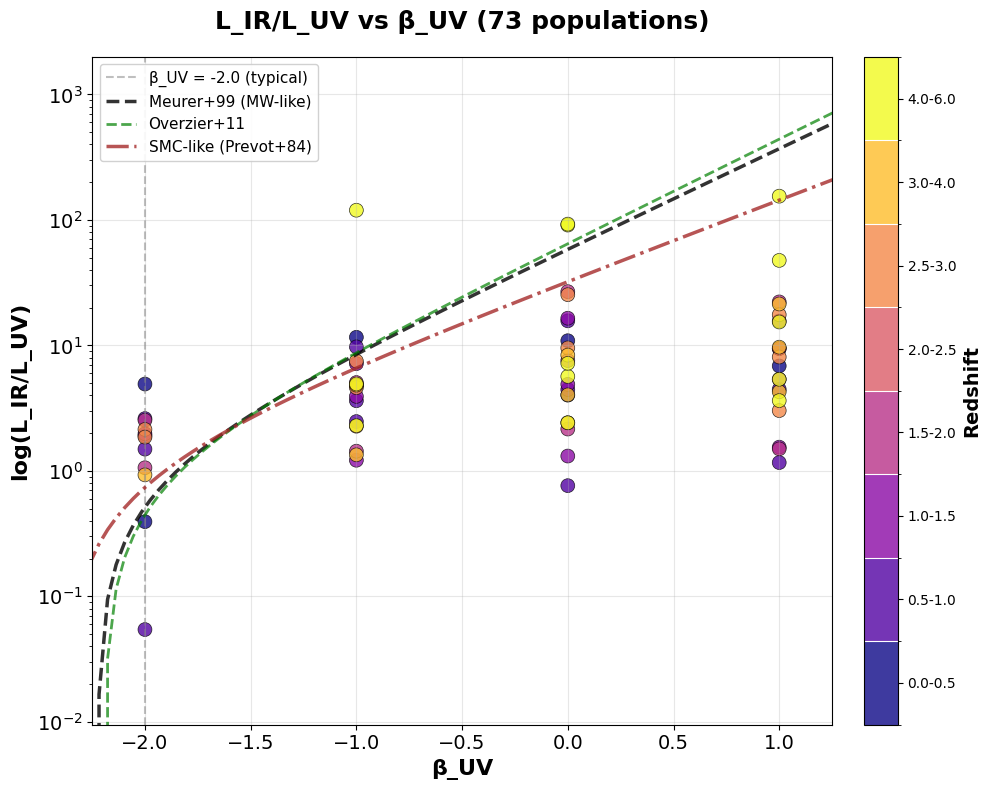

In [17]:
lir_luv_beta = create_lir_luv_beta_plot(wrapper, xlim=[-2.25,1.25])

In [18]:
def create_lir_luv_beta_plot(
    wrapper, 
    show_errors=True,
    figsize=(8, 7),
    color_by='redshift',
    average_luv_per_z=True,
    save_path=None, 
    xlim=None, 
    ylim=None
):
    """
    Create L_IR/L_UV vs β_UV plot from SimstackWrapper results
    
    Parameters:
    -----------
    wrapper : SimstackWrapper
        Wrapper object with stacking_results and processed_results
    show_errors : bool
        Whether to show error bars
    figsize : tuple
        Figure size (width, height)
    color_by : str
        What to color points by: 'redshift' (default) or 'l_uv'
    average_luv_per_z : bool
        Whether to average L_UV bins within each redshift bin
    save_path : str or Path or None
        Path to save the figure (PDF, PNG, etc. based on extension)
    """
    
    # Get results from wrapper
    if not hasattr(wrapper, 'stacking_results') or wrapper.stacking_results is None:
        print("❌ No stacking results found in wrapper")
        return None
        
    if not hasattr(wrapper, 'processed_results') or wrapper.processed_results is None:
        print("❌ No processed results found in wrapper")
        return None
    
    # Get summary dataframe
    try:
        if hasattr(wrapper.processed_results, 'get_population_summary'):
            summary_df = wrapper.processed_results.get_population_summary()
        else:
            summary_df = wrapper.population_manager.get_population_summary()
        
        print(f"📋 Available columns: {list(summary_df.columns)}")
        
    except Exception as e:
        print(f"❌ Could not get population summary: {e}")
        return None
    
    # Determine the correct population ID column name
    pop_id_col = None
    possible_id_cols = ['id_label', 'population_id', 'pop_id', 'label']
    
    for col in possible_id_cols:
        if col in summary_df.columns:
            pop_id_col = col
            break
    
    if pop_id_col is None:
        print(f"❌ Could not find population ID column. Available columns: {list(summary_df.columns)}")
        return None
    
    # Filter for detected populations only
    df = summary_df.copy()
    
    # Check if we have L_IR measurements
    lir_cols = [col for col in df.columns if 'ir_luminosity' in col.lower()]
    if not lir_cols:
        print("❌ No L_IR measurements found")
        return None
    
    lir_col = lir_cols[0]
    df = df[df[lir_col] > 0]
    print(f"🔍 Using {lir_col} for L_IR")
    
    if len(df) == 0:
        print("❌ No detected populations found")
        return None
    
    print(f"✅ Found {len(df)} detected populations")
    
    # Parse population information to extract β_UV and L_UV
    def parse_population_id(pop_id):
        """Extract binning information from population ID"""
        try:
            parts = pop_id.split('__')
            bin_info = {}
            
            for part in parts:
                if '_' in part:
                    elements = part.split('_')
                    if len(elements) >= 3:
                        try:
                            min_val = float(elements[-2])
                            max_val = float(elements[-1])
                            bin_name = '_'.join(elements[:-2])
                            bin_info[bin_name] = (min_val, max_val)
                        except ValueError:
                            continue
            
            return bin_info
        except Exception as e:
            print(f"⚠️  Could not parse population ID: {pop_id}")
            return {}
    
    # Parse all population IDs
    parsed_info = df[pop_id_col].apply(parse_population_id)
    
    # Extract β_UV, L_UV, and redshift values
    beta_uv_values = []
    l_uv_values = []
    redshift_values = []
    l_ir_luv_ratios = []
    
    # Color scheme for population types (backup if not using colorbar)
    has_split = any('split' in str(pop_id) for pop_id in df[pop_id_col])
    
    for idx, (_, pop) in enumerate(df.iterrows()):
        pop_id = pop[pop_id_col]
        bin_info = parsed_info.iloc[idx]
        
        # Extract β_UV and redshift from binning
        beta_uv = None
        l_uv = None
        redshift = None
        
        for bin_name, (min_val, max_val) in bin_info.items():
            if 'beta' in bin_name.lower():
                beta_uv = (min_val + max_val) / 2  # Use bin center
            elif 'l_uv' in bin_name.lower() or 'luv' in bin_name.lower():
                l_uv = (min_val + max_val) / 2  # Use bin center
            elif 'redshift' in bin_name.lower() or bin_name.lower() == 'z':
                redshift = (min_val + max_val) / 2  # Use bin center
        
        # Also try to get redshift from median_redshift column
        if redshift is None and 'median_redshift' in pop:
            redshift = pop['median_redshift']
        
        # Get L_IR
        l_ir = pop[lir_col]
        
        # Only include if we have all required values
        if beta_uv is not None and l_uv is not None and l_ir > 0:
            beta_uv_values.append(beta_uv)
            l_uv_values.append(l_uv)
            redshift_values.append(redshift if redshift is not None else np.nan)
            
            # Calculate L_IR/L_UV ratio
            # L_UV is in log space, so convert: L_UV = 10^l_uv
            l_uv_linear = 10**l_uv
            l_ir_luv_ratio = np.log10(l_ir / l_uv_linear)
            l_ir_luv_ratios.append(l_ir_luv_ratio)
    
    if len(beta_uv_values) == 0:
        print("❌ No populations found with both β_UV and L_UV binning")
        return None
    
    print(f"📊 Found {len(beta_uv_values)} populations with β_UV and L_UV data")
    
    # Convert to arrays
    beta_uv_values = np.array(beta_uv_values)
    l_uv_values = np.array(l_uv_values)
    redshift_values = np.array(redshift_values)
    l_ir_luv_ratios = np.array(l_ir_luv_ratios)
    
    # Average L_UV bins per redshift if requested
    if average_luv_per_z and np.any(np.isfinite(redshift_values)):
        print("🔄 Averaging L_UV bins within each redshift bin...")
        
        # Group by redshift and beta_UV bins
        unique_combinations = []
        averaged_data = []
        
        for i, (beta, z) in enumerate(zip(beta_uv_values, redshift_values)):
            if not np.isfinite(z):
                continue
                
            # Round to find matching redshift/beta bins
            z_rounded = round(z, 1)  # Round to 0.1
            beta_rounded = round(beta, 1)  # Round to 0.1
            
            key = (z_rounded, beta_rounded)
            
            # Check if this combination already exists
            found = False
            for j, (existing_key, existing_data) in enumerate(unique_combinations):
                if existing_key == key:
                    # Add to existing group
                    existing_data['l_uv_list'].append(l_uv_values[i])
                    existing_data['l_ir_luv_list'].append(l_ir_luv_ratios[i])
                    found = True
                    break
            
            if not found:
                # Create new group
                unique_combinations.append((key, {
                    'z': z,
                    'beta': beta,
                    'l_uv_list': [l_uv_values[i]],
                    'l_ir_luv_list': [l_ir_luv_ratios[i]]
                }))
        
        # Calculate averages
        if len(unique_combinations) > 0:
            beta_uv_values_avg = []
            l_uv_values_avg = []
            redshift_values_avg = []
            l_ir_luv_ratios_avg = []
            
            for (z_rounded, beta_rounded), data in unique_combinations:
                beta_uv_values_avg.append(data['beta'])
                redshift_values_avg.append(data['z'])
                l_uv_values_avg.append(np.mean(data['l_uv_list']))
                l_ir_luv_ratios_avg.append(np.mean(data['l_ir_luv_list']))
            
            # Replace with averaged values
            beta_uv_values = np.array(beta_uv_values_avg)
            l_uv_values = np.array(l_uv_values_avg)
            redshift_values = np.array(redshift_values_avg)
            l_ir_luv_ratios = np.array(l_ir_luv_ratios_avg)
            
            print(f"✅ Averaged to {len(beta_uv_values)} unique redshift/β_UV combinations")
    
    # Create the plot
    fig, ax = plt.subplots(1, 1, figsize=figsize)
    
    # Determine what to color by
    if color_by == 'l_uv':
        color_values = l_uv_values
        color_label = 'log L_UV/L_☉'
        cmap = 'viridis'
    else:  # default to redshift
        color_values = redshift_values
        color_label = 'Redshift'
        cmap = 'plasma'
    
    # Check if we have valid color values
    valid_color_mask = np.isfinite(color_values)
    if not np.any(valid_color_mask):
        print(f"⚠️  No valid {color_by} values found, using default colors")
        # Fall back to discrete colors
        scatter = ax.scatter(beta_uv_values, l_ir_luv_ratios, 
                            c='blue', s=100, alpha=0.8, 
                            edgecolors='black', linewidth=0.5)
        colorbar_created = False
    else:
        # Use colormap - but be careful with color values
        import matplotlib.cm as cm
        from matplotlib.colors import Normalize
        
        # Only use valid points for colormap normalization
        valid_color_values = color_values[valid_color_mask]
        norm = Normalize(vmin=np.min(valid_color_values), vmax=np.max(valid_color_values))
        
        # Plot points with colormap - use scalar values, not arrays
        scatter = ax.scatter(beta_uv_values, l_ir_luv_ratios, 
                            c=color_values, cmap=cmap, s=100, alpha=0.8, 
                            edgecolors='black', linewidth=0.5, norm=norm)
        
        # Add colorbar
        cbar = plt.colorbar(scatter, ax=ax, fraction=0.046, pad=0.04)
        cbar.set_label(color_label, fontsize=14, fontweight='bold')
        cbar.ax.tick_params(labelsize=12)
        colorbar_created = True
    
    # Set labels and scale
    ax.set_xlabel('β_UV', fontsize=16, fontweight='bold')
    ax.set_ylabel('L_IR/L_UV', fontsize=16, fontweight='bold')
    #ax.set_yscale('log')
    if ylim is not None:
        ax.set_ylim(ylim)
    else:
        ax.set_ylim(np.log10([5e-3,2e3]))
    ax.tick_params(axis='both', which='major', labelsize=14)
    ax.grid(True, alpha=0.3)
    
    # Add title
    title = f"L_IR/L_UV vs β_UV ({len(beta_uv_values)} populations)"
    ax.set_title(title, fontsize=18, fontweight='bold', pad=20)
    
    # Add legend for population types if we have them and not using colorbar
    if has_split and not colorbar_created:
        from matplotlib.patches import Patch
        legend_elements = [Patch(facecolor='red', alpha=0.6, label='Star-forming'),
                          Patch(facecolor='teal', alpha=0.6, label='Quiescent')]
        ax.legend(handles=legend_elements, loc='upper left', fontsize=12, frameon=True,
                 title='Population Type', title_fontsize=12)
    
    # Set reasonable limits
    if xlim is not None:
        ax.set_xlim(xlim)
    else:
        ax.set_xlim(np.min(beta_uv_values) - 0.2, np.max(beta_uv_values) + 0.2)
    
    # Add some reference lines if useful
    if np.min(beta_uv_values) < -1 and np.max(beta_uv_values) > 0:
        ax.axvline(x=-2.0, color='gray', linestyle='--', alpha=0.5, label='β_UV = -2.0 (typical)')
    
    # Literature relations
    beta_model = np.linspace(-2.5, 1.5, 100)
    irx_meurer = np.log10(10**(0.4 * (4.43 + 1.99 * beta_model)) - 1) + 0.076
    #ax.plot(beta_model, irx_meurer, 'k--', linewidth=2, alpha=0.8, label='Meurer+99')
    irx_overzier = np.log10(10**(0.4 * (4.54 + 2.07 * beta_model)) - 1) + 0.225
    ax.plot(beta_model, irx_overzier, 'k--', linewidth=2, alpha=0.8, label='Overzier+11')
    plt.tight_layout()
    
    # Save figure if path provided
    if save_path is not None:
        try:
            from pathlib import Path
            save_path = Path(save_path)
            save_path.parent.mkdir(parents=True, exist_ok=True)
            
            dpi = 300 if save_path.suffix.lower() in ['.png', '.jpg', '.jpeg'] else 150
            plt.savefig(save_path, dpi=dpi, bbox_inches='tight', 
                       facecolor='white', edgecolor='none')
            print(f"💾 Figure saved to: {save_path}")
            
        except Exception as e:
            print(f"⚠️  Could not save figure: {e}")
    
    # Print summary
    print(f"\n📈 Plot Summary:")
    print(f"   β_UV range: {np.min(beta_uv_values):.2f} to {np.max(beta_uv_values):.2f}")
    print(f"   L_UV range: {np.min(l_uv_values):.2f} to {np.max(l_uv_values):.2f}")
    if np.any(valid_color_mask):
        print(f"   {color_label} range: {np.min(valid_color_values):.2f} to {np.max(valid_color_values):.2f}")
    print(f"   L_IR/L_UV range: {np.min(l_ir_luv_ratios):.2e} to {np.max(l_ir_luv_ratios):.2e}")
    print(f"   Median L_IR/L_UV: {np.median(l_ir_luv_ratios):.2e}")
    print(f"   Colored by: {color_by}")
    if average_luv_per_z:
        print(f"   L_UV values averaged within redshift/β_UV bins")
    
    return fig

📋 Available columns: ['population_id', 'n_sources', 'median_redshift', 'median_log_mass', 'n_bands', 'greybody_fit_success', 'dust_temperature_rest_frame_K', 'dust_temperature_observed_frame_K', 'dust_temperature_error_K', 'emissivity_index', 'chi2_reduced', 'total_ir_luminosity_lsun', 'total_ir_luminosity_error_lsun', 'dust_mass_msun', 'sfr_msun_yr', 'specific_sfr_yr']
🔍 Using total_ir_luminosity_lsun for L_IR
✅ Found 78 detected populations
📊 Found 78 populations with β_UV and L_UV data
🔄 Averaging L_UV bins within each redshift bin...
✅ Averaged to 31 unique redshift/β_UV combinations
💾 Figure saved to: /Users/mviero/Desktop/IRX-binned.png

📈 Plot Summary:
   β_UV range: -2.00 to 1.00
   L_UV range: 9.50 to 11.00
   Redshift range: 0.26 to 7.50
   L_IR/L_UV range: -9.69e+00 to 3.34e+00
   Median L_IR/L_UV: -2.62e-01
   Colored by: redshift
   L_UV values averaged within redshift/β_UV bins


/var/folders/y6/w9q_b49n5qzbxrbqfjs4qkpm0000gn/T/ipykernel_37487/1660546822.py:293: RuntimeWarning: invalid value encountered in log10
  irx_meurer = np.log10(10**(0.4 * (4.43 + 1.99 * beta_model)) - 1) + 0.076
/var/folders/y6/w9q_b49n5qzbxrbqfjs4qkpm0000gn/T/ipykernel_37487/1660546822.py:295: RuntimeWarning: invalid value encountered in log10
  irx_overzier = np.log10(10**(0.4 * (4.54 + 2.07 * beta_model)) - 1) + 0.225


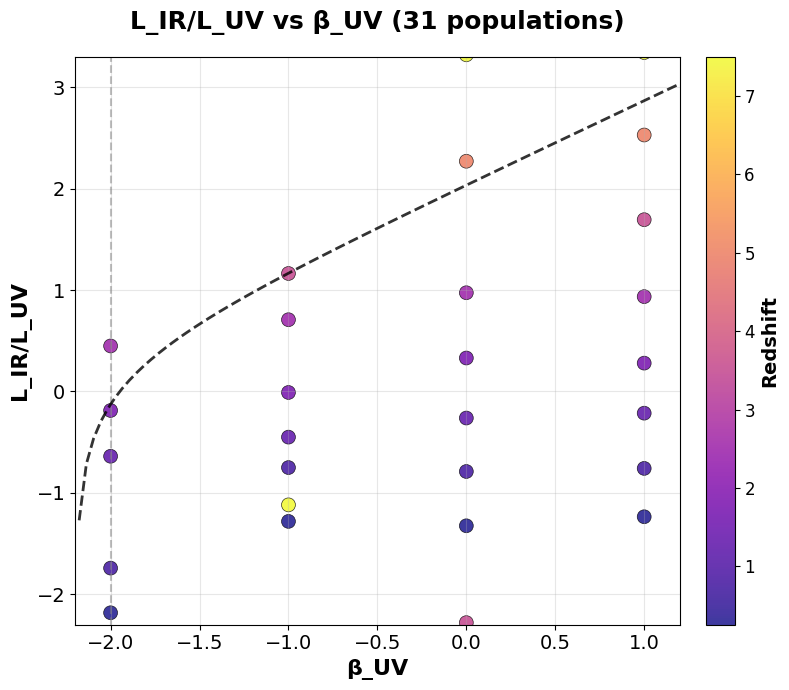

In [19]:
fig = create_lir_luv_beta_plot(
    wrapper, 
    color_by='redshift', 
    average_luv_per_z=True,
    save_path='/Users/mviero/Desktop/IRX-binned.png'
)

📋 Available columns: ['population_id', 'n_sources', 'median_redshift', 'median_log_mass', 'n_bands', 'greybody_fit_success', 'dust_temperature_rest_frame_K', 'dust_temperature_observed_frame_K', 'dust_temperature_error_K', 'emissivity_index', 'chi2_reduced', 'total_ir_luminosity_lsun', 'total_ir_luminosity_error_lsun', 'dust_mass_msun', 'sfr_msun_yr', 'specific_sfr_yr']
🔍 Using total_ir_luminosity_lsun for L_IR
✅ Found 73 detected populations
📊 Found 73 populations with β_UV and L_UV data
🔄 Averaging L_UV bins within each redshift bin...
✅ Averaged to 30 unique redshift/β_UV combinations
💾 Figure saved to: /Users/mviero/Desktop/IRX-binned.png

📈 Plot Summary:
   β_UV range: -2.00 to 1.00
   L_UV range: 9.50 to 11.50
   Redshift range: 0.26 to 7.50
   L_IR/L_UV range: -2.25e-01 to 1.43e+00
   Median L_IR/L_UV: 6.89e-01
   Colored by: redshift
   L_UV values averaged within redshift/β_UV bins


/var/folders/y6/w9q_b49n5qzbxrbqfjs4qkpm0000gn/T/ipykernel_46415/2084461012.py:303: RuntimeWarning: invalid value encountered in log10
  irx_meurer = np.log10(10**(0.4 * (4.43 + 1.99 * beta_model)) - 1) + 0.076
/var/folders/y6/w9q_b49n5qzbxrbqfjs4qkpm0000gn/T/ipykernel_46415/2084461012.py:305: RuntimeWarning: invalid value encountered in log10
  irx_overzier = np.log10(10**(0.4 * (4.54 + 2.07 * beta_model)) - 1) + 0.225


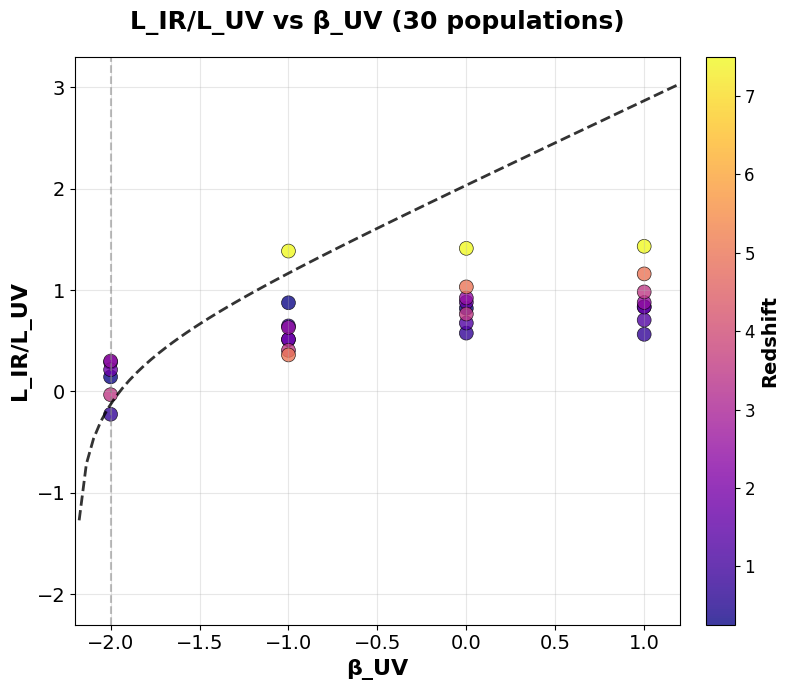

In [19]:
fig = create_lir_luv_beta_plot(
    wrapper, 
    color_by='redshift', 
    average_luv_per_z=True,
    save_path='/Users/mviero/Desktop/IRX-binned.png'
)

📋 Available columns: ['population_id', 'n_sources', 'median_redshift', 'median_log_mass', 'n_bands', 'greybody_fit_success', 'dust_temperature_rest_frame_K', 'dust_temperature_observed_frame_K', 'dust_temperature_error_K', 'emissivity_index', 'chi2_reduced', 'total_ir_luminosity_lsun', 'total_ir_luminosity_error_lsun', 'dust_mass_msun', 'sfr_msun_yr', 'specific_sfr_yr']
🔍 Using total_ir_luminosity_lsun for L_IR
✅ Found 73 detected populations
📊 Found 73 populations with β_UV and L_UV data
🔄 Averaging L_UV bins within each redshift bin...
✅ Averaged to 30 unique redshift/β_UV combinations
💾 Figure saved to: /Users/mviero/Desktop/IRX-binned.png

📈 Plot Summary:
   β_UV range: -2.00 to 1.00
   L_UV range: 9.50 to 11.50
   Redshift range: 0.26 to 7.50
   L_IR/L_UV range: -2.25e-01 to 1.43e+00
   Median L_IR/L_UV: 6.89e-01
   Colored by: redshift
   L_UV values averaged within redshift/β_UV bins


/var/folders/y6/w9q_b49n5qzbxrbqfjs4qkpm0000gn/T/ipykernel_45326/2084461012.py:303: RuntimeWarning: invalid value encountered in log10
  irx_meurer = np.log10(10**(0.4 * (4.43 + 1.99 * beta_model)) - 1) + 0.076
/var/folders/y6/w9q_b49n5qzbxrbqfjs4qkpm0000gn/T/ipykernel_45326/2084461012.py:305: RuntimeWarning: invalid value encountered in log10
  irx_overzier = np.log10(10**(0.4 * (4.54 + 2.07 * beta_model)) - 1) + 0.225


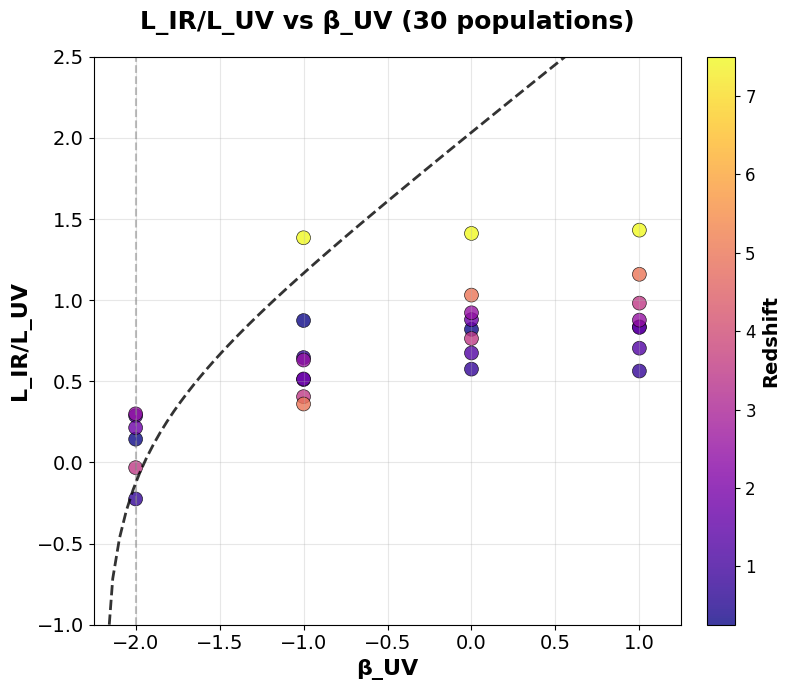

In [44]:
fig = create_lir_luv_beta_plot(
    wrapper, 
    color_by='redshift', 
    average_luv_per_z=True,
    save_path='/Users/mviero/Desktop/IRX-binned.png',
    xlim=[-2.25,1.25],
    ylim=[-1,2.5]
)